In [1]:
import pandas as pd
import yaml
import os
import openpyxl
import pygwalker as pyg
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import sys
from pathlib import Path

In [2]:
# To add project files
# Keeps going up project structure until it gets to the root.
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69a5ff07-91e0-8329-88d1-cf2ea6c159c2
project_root = Path().resolve()
while project_root.name != "AFOLU_GHG_flux_model":
    project_root = project_root.parent

sys.path.append(str(project_root))

from src.utilities import constants_and_names as cn

In [3]:
model_version = '1_0_5'
chunk_stats_folder = f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/v{model_version}_standard_global/'
parquet_name = f'veg_model_zonal_stats_v{model_version}_20260224_19_21_07.parquet'

In [4]:
%%time

# Reads gross outputs parquet table
df_raw = pd.read_parquet(f'{chunk_stats_folder}{parquet_name}')
df_raw["country_name"] = df_raw["country_name"].replace({         # Renames some countries with long names
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Russian Federation": "Russia",
    "Democratic Republic of the Congo": "DR Congo",
    "United States of America (the)": "USA"
})

# Create new column that separates out high protection status
# https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69aee45e-ce6c-8325-b1d0-a6c6b0e7ae2e
df_raw["WDPA_high_protection"] = "Other protection status"

df_raw.loc[df_raw["WDPA_type"] == "NA", "WDPA_high_protection"] = "Not protected"
df_raw.loc[df_raw["WDPA_type"].isin(["Cateogry Ia", "Category Ib", "Category II", "Category III"]), "WDPA_high_protection"] = "High protection"

print(f"Rows in df: {len(df_raw)}")
# df_raw.head(10)

Rows in df: 27999047
CPU times: user 27.4 s, sys: 7.28 s, total: 34.7 s
Wall time: 14.3 s


In [5]:
%%time

layers_to_drop = [
    "carbon_density__non_soil__MgC_ha",
    cn.agc_gross_emis_pattern,
    cn.bgc_gross_emis_pattern,
    cn.deadwood_c_gross_emis_pattern,
    cn.litter_c_gross_emis_pattern,
    cn.net_flux_all_C_pools_CO2_only_pattern,
    cn.agc_gross_removals_pattern,
    cn.bgc_gross_removals_pattern,
    cn.deadwood_c_gross_removals_pattern,
    cn.litter_c_gross_removals_pattern,
    cn.net_flux_agc_pattern,
    cn.net_flux_bgc_pattern,
    cn.net_flux_deadwood_c_pattern,
    cn.net_flux_litter_c_pattern,
    cn.ch4_gross_emis_pattern,
    cn.n2o_gross_emis_pattern
]

df_graphs = df_raw[~df_raw["analysis_layer"].isin(layers_to_drop)].reset_index(drop=True)
state_node_df = pd.read_excel(cn.state_node_lookup_table_local, sheet_name=cn.sheet)
df_graphs = df_graphs.merge(state_node_df[['land_state', 'tall_veg_type']],  # Merge tall_veg_type field from state_node_df
          left_on='land_state_node', right_on='land_state',
          how='left')
print(f"Rows in df: {len(df_graphs)}")
# df_graphs

Rows in df: 8178188
CPU times: user 3 s, sys: 1.87 s, total: 4.87 s
Wall time: 4.96 s


Figure creation

In [6]:
# General code

years = len(cn.interval_end_years_annual)

gross_emis_all_gases_legend = "Gross emissions (all gases)"
gross_emis_CO2_legend = "Gross emissions (CO₂ only)"
gross_emis_non_CO2_legend = "Gross emissions (non-CO₂)"
net_flux_all_gases_legend = "Net flux (all gases)"
gross_removals_legend = "Gross removals"

broad_class_dict = {
    "tree": "Tall vegetation",
    "short_veg": "Short vegetation",
    "crop": "Cropland"
}

detailed_class_dict = {
    "tree_tree_undisturbed": "Undisturbed (except for fires) tall veg",
    "tree_tree_disturbed": "Partially disturbed tall veg", 
    "tree_loss": "Tall veg loss",
    "tree_gain": "Tall veg gain",
    "short_veg_short_veg_undisturbed": "Stable short veg",
    "short_veg_gain": "Short veg gain",
    "short_veg_loss": "Short veg loss", 
    "crop_crop_undisturbed": "Stable cropland",
    "crop_gain": "Cropland gain",
    "crop_loss": "Cropland loss"
}

tall_veg_type_dict = {
    "mangrove": "Mangrove",
    "oil_palm": "Oil palm",
    "non_oil_palm_planted_trees": "Non-oil palm planted trees",
    "natural_tree_cover": "Natural tree cover",
    "trees_in_other_land_covers": "Trees in other land covers",
    "non_tall_vegetation": "Non-tall vegetation"
}

primary_forest_dict = {
    0: "Not primary forest",
    1: "Primary forest"
}

tall_veg_change_type_classes = [
    "Tall veg loss",
    "Tall veg gain",
    "Partially disturbed tall veg",
    "Undisturbed (except for fires) tall veg"
]

# Aggregates by analysis layer
def aggregate_layer(df, pattern):
    d = df[df["analysis_layer"] == pattern]
    d = (
        d.groupby([context_to_analyze, "year"], as_index=False)
         .agg({"value": "sum"})
    )
    d["value_Gt"] = d["value"] / 1e9
    return d

In [7]:
sns.set_theme(style="white", context="talk")

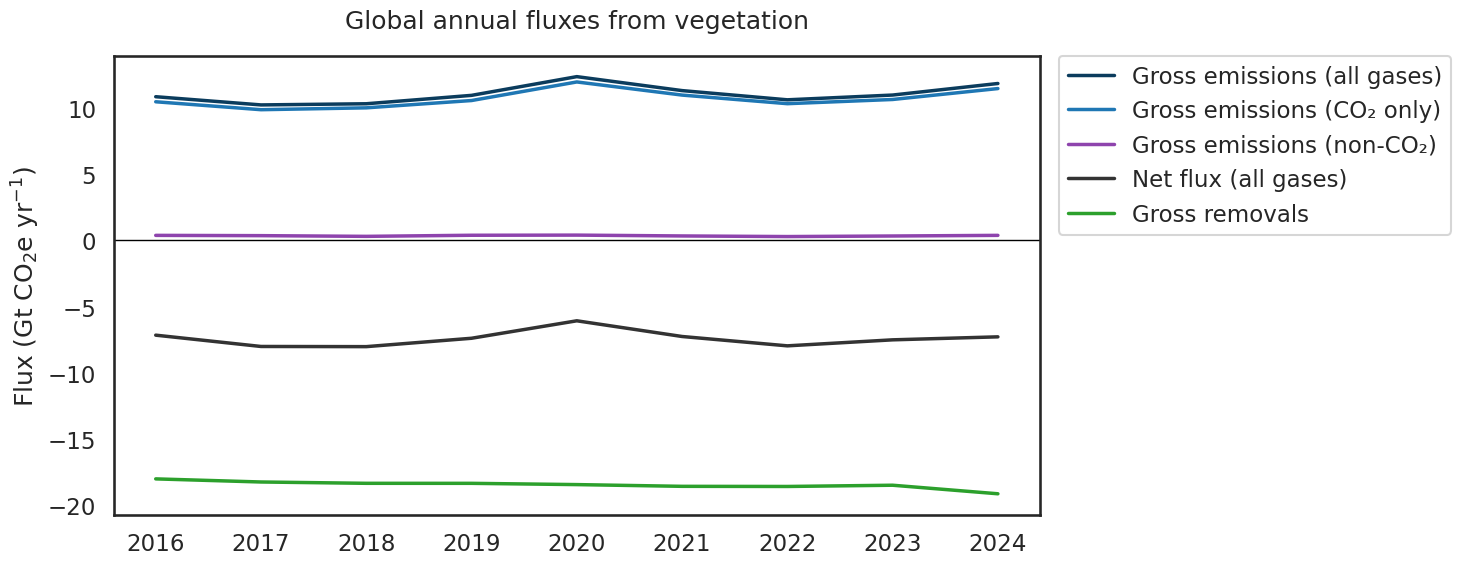

In [8]:
### Global emissions, removals, net flux timeseries (single panel)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69a5f52d-4db0-832e-8a7e-ee14ee9ac9d0

df_fig = df_graphs.copy()

df_ts = (
    df_fig
    .groupby(["analysis_layer", "year"], as_index=False)
    .agg({"value": "sum"})
)

# Convert to Gt CO2e
df_ts["value_Gt"] = df_ts["value"] / 1e9

layer_labels = {
    cn.gross_emis_all_C_pools_CO2_only_pattern:
        gross_emis_CO2_legend,
    cn.gross_emis_all_C_pools_non_CO2_only_pattern:
        gross_emis_non_CO2_legend,
    cn.gross_emis_all_C_pools_all_gases_pattern:
        gross_emis_all_gases_legend,
    cn.gross_removals_all_C_pools_pattern:
        gross_removals_legend,
    cn.net_flux_all_C_pools_all_gases_pattern:
        net_flux_all_gases_legend,
}

# Custom color mapping aligned with desired_order
custom_palette = {
    gross_emis_all_gases_legend: "#0b3c5d",      # deep navy
    gross_emis_CO2_legend: "#1f77b4",       # strong blue
    gross_emis_non_CO2_legend: "#8e44ad",        # saturated violet
    net_flux_all_gases_legend: "#333333",             # charcoal (neutral emphasis)
    gross_removals_legend: "#2ca02c",                   # green
}

df_ts["layer_label"] = df_ts["analysis_layer"].map(layer_labels)

# Desired legend order
desired_order = [
    gross_emis_all_gases_legend,
    gross_emis_CO2_legend,
    gross_emis_non_CO2_legend,
    net_flux_all_gases_legend,
    gross_removals_legend,
]

# Make categorical with order
df_ts["layer_label"] = pd.Categorical(
    df_ts["layer_label"],
    categories=desired_order,
    ordered=True
)

plt.figure(figsize=(15, 6))

ax = sns.lineplot(
    data=df_ts,
    x="year",
    y="value_Gt",
    hue="layer_label",
    hue_order=desired_order,
    palette=custom_palette,
    linewidth=2.5
)

# Zero reference line
ax.axhline(0, color="black", linewidth=1)

# Remove any gridlines
ax.grid(False)

ax.set_xlabel(None)
ax.set_ylabel("Flux (Gt CO$_2$e yr$^{-1}$)")

# Title
ax.set_title("Global annual fluxes from vegetation", pad=20)

# Legend outside right
ax.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

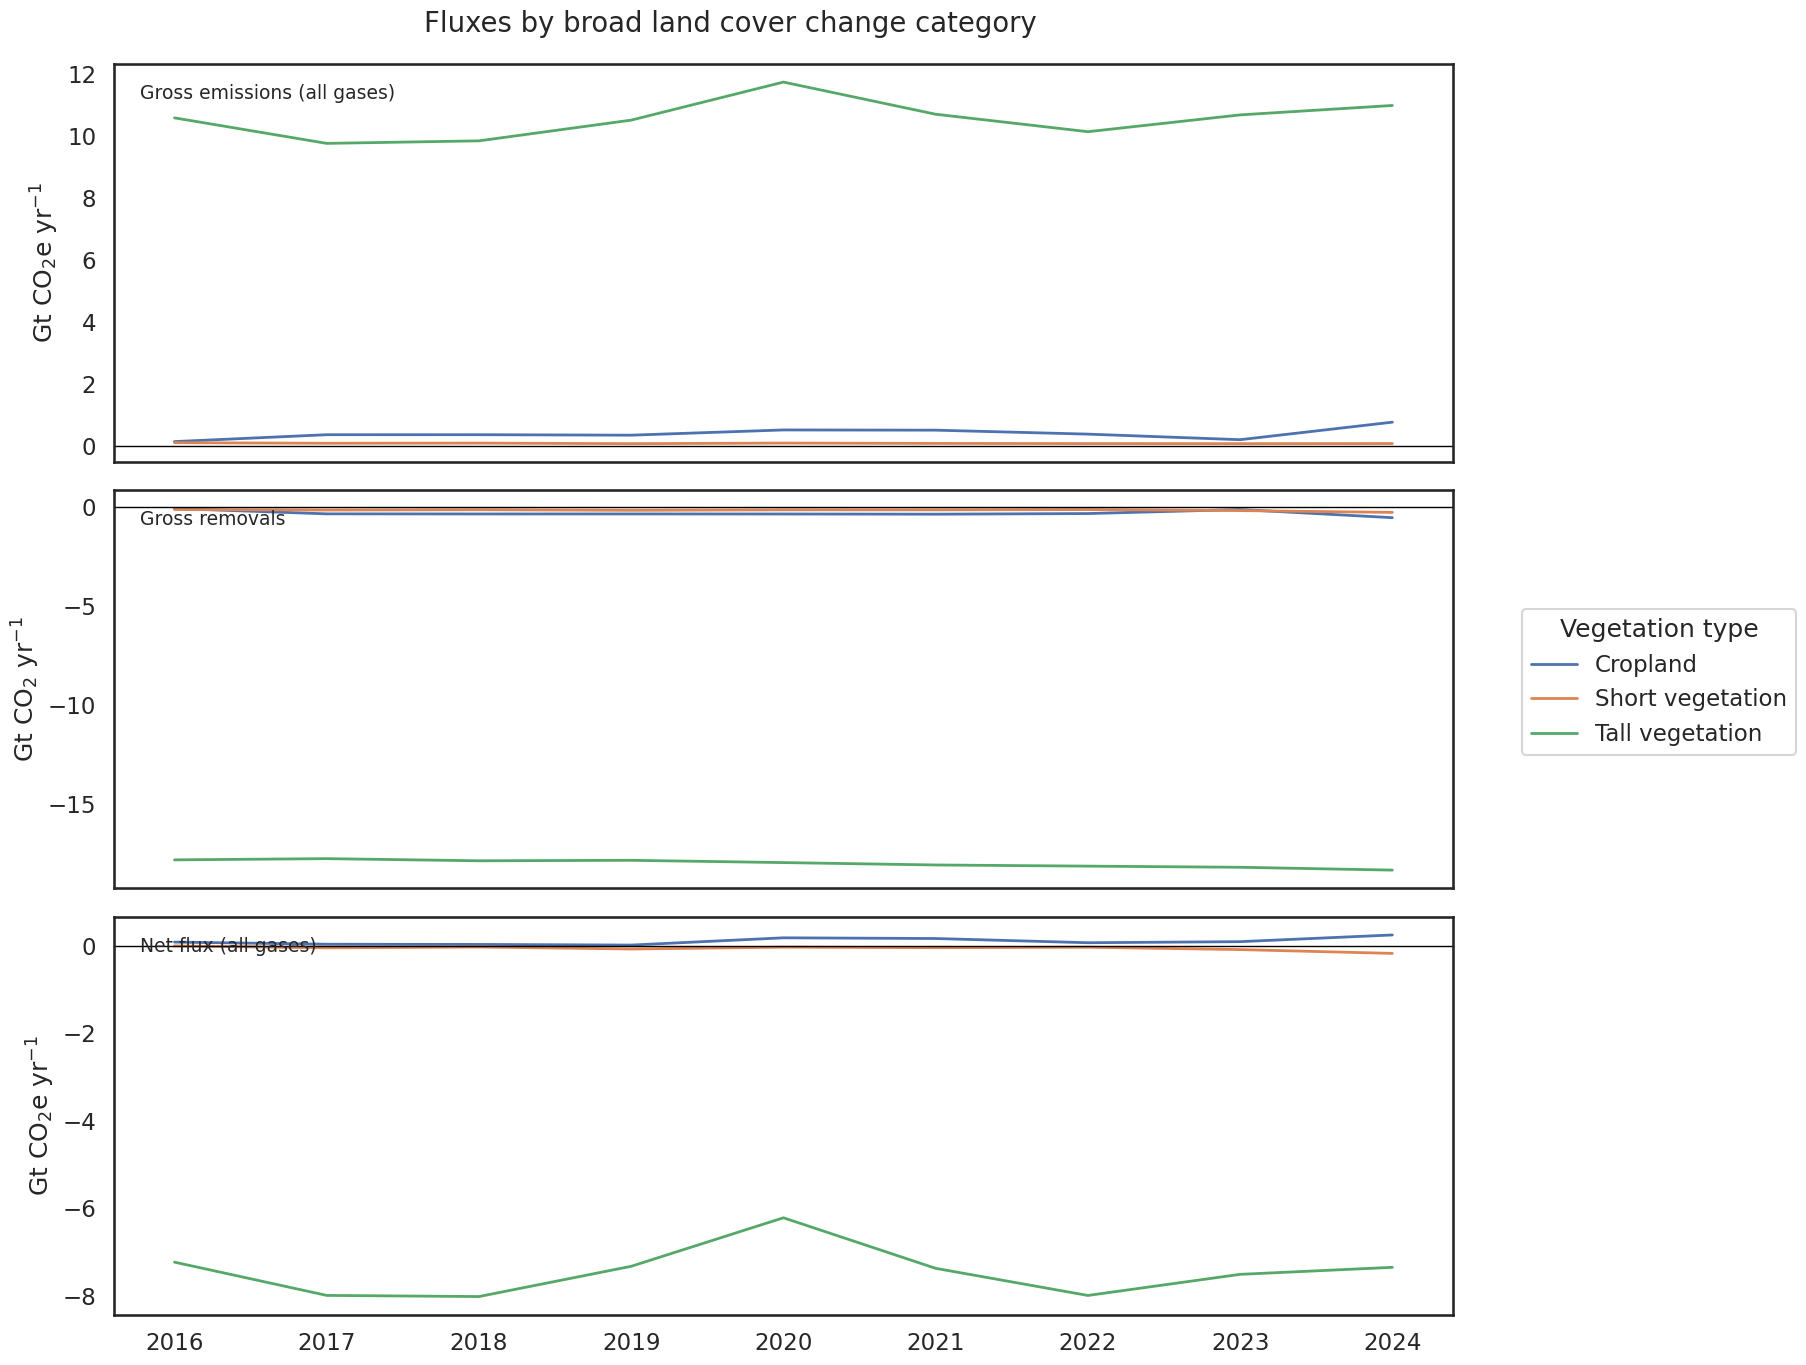

In [9]:
### Global emissions, removals, net flux timeseries by vegetation type (flux per panel)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69a5f52d-4db0-832e-8a7e-ee14ee9ac9d0

# ---- Setup ----
context_to_analyze = 'land_state_broad_class'

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(15, 14),
    sharex=True
)

panel_labels = [
    gross_emis_all_gases_legend,
    gross_removals_legend,
    net_flux_all_gases_legend
]

# Patterns
emis_pattern = cn.gross_emis_all_C_pools_all_gases_pattern
remov_pattern = cn.gross_removals_all_C_pools_pattern
net_pattern = cn.net_flux_all_C_pools_all_gases_pattern

df_fig = df_graphs.copy()

df_emis = aggregate_layer(df_fig, emis_pattern)
df_remov = aggregate_layer(df_fig, remov_pattern)
df_net = aggregate_layer(df_fig, net_pattern)

# Map to interpretable labels
df_emis[context_to_analyze] = df_emis[context_to_analyze].map(broad_class_dict)
df_remov[context_to_analyze] = df_remov[context_to_analyze].map(broad_class_dict)
df_net[context_to_analyze] = df_net[context_to_analyze].map(broad_class_dict)


# ---- Panel 1 ----
sns.lineplot(
    data=df_emis,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[0],
    linewidth=2
)

axes[0].axhline(0, color="black", linewidth=1)
axes[0].grid(False)
axes[0].set_ylabel("Gt CO$_2$e yr$^{-1}$")

axes[0].text(
    0.02, 0.95,
    panel_labels[0],
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 2 ----
sns.lineplot(
    data=df_remov,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[1],
    linewidth=2,
    legend=False
)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].grid(False)
axes[1].set_ylabel("Gt CO$_2$ yr$^{-1}$")

axes[1].text(
    0.02, 0.95,
    panel_labels[1],
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 3 ----
sns.lineplot(
    data=df_net,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[2],
    linewidth=2,
    legend=False
)

axes[2].axhline(0, color="black", linewidth=1)
axes[2].grid(False)
axes[2].set_ylabel("Gt CO$_2$e yr$^{-1}$")
axes[2].set_xlabel(None)

axes[2].text(
    0.02, 0.95,
    panel_labels[2],
    transform=axes[2].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Single legend outside right ----
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Vegetation type",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

axes[0].legend().remove()

fig.suptitle(
    "Fluxes by broad land cover change category",
    fontsize=plt.rcParams["axes.titlesize"] * 1.1,
    y=0.98
)

plt.tight_layout()
plt.show()

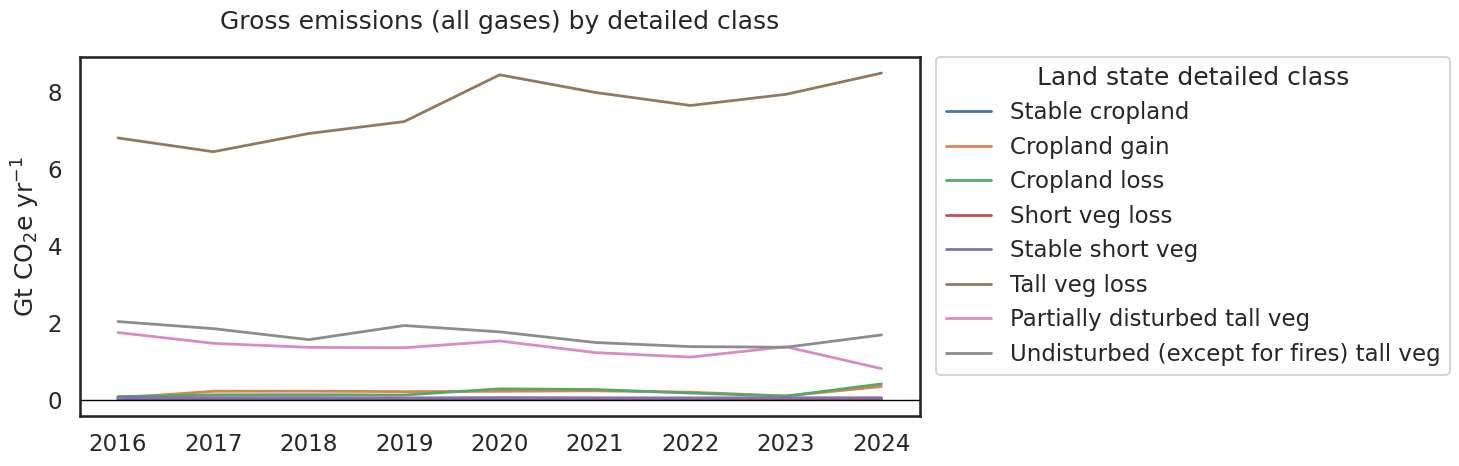

In [10]:
### Global gross emissions timeseries by 10 land cover change categories (single panel)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69a5f52d-4db0-832e-8a7e-ee14ee9ac9d0

# ---- Setup ----
context_to_analyze = "land_state_detailed_class"

df_fig = df_graphs.copy()

# Filter to gross emissions (all gases)
df_emis = df_fig[
    df_fig["analysis_layer"] == cn.gross_emis_all_C_pools_all_gases_pattern
]

# Aggregate
df_emis_ts = (
    df_emis
    .groupby([context_to_analyze, "year"], as_index=False)
    .agg({"value": "sum"})
)

df_emis_ts["value_Gt"] = df_emis_ts["value"] / 1e9

# Map to readable labels
df_emis_ts["legend_label"] = df_emis_ts[context_to_analyze].map(detailed_class_dict)

# If some classes are missing from dictionary, keep original
df_emis_ts["legend_label"] = df_emis_ts["legend_label"].fillna(
    df_emis_ts[context_to_analyze]
)

# ---- Plot ----
sns.set_theme(style="white", context="talk")

plt.figure(figsize=(15, 5))

ax = sns.lineplot(
    data=df_emis_ts,
    x="year",
    y="value_Gt",
    hue="legend_label",
    linewidth=2
)

ax.axhline(0, color="black", linewidth=1)
ax.grid(False)

ax.set_xlabel(None)
ax.set_ylabel("Gt CO$_2$e yr$^{-1}$")
ax.set_title("Gross emissions (all gases) by detailed class", pad=20)

# Legend outside right
ax.legend(
    title="Land state detailed class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

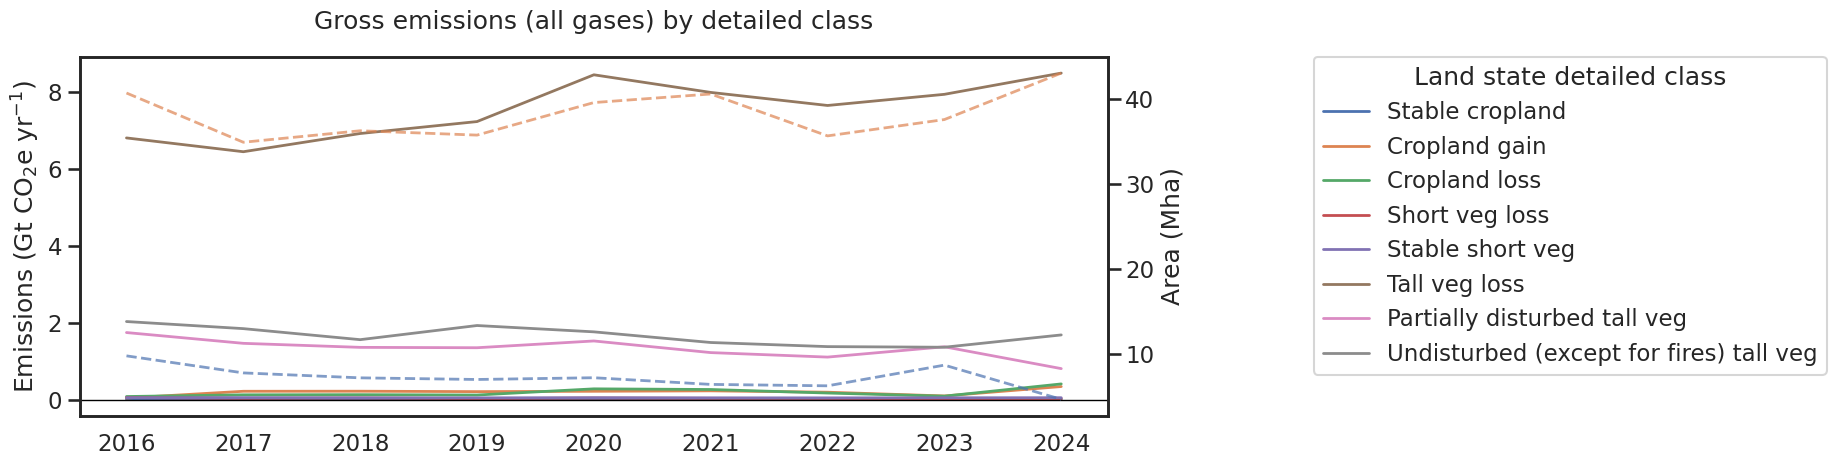

In [11]:
### Global gross emissions timeseries by 10 land cover change categories, with area of tree loss and disturbed trees mapped on secondary y-axis (single panel)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69a5f52d-4db0-832e-8a7e-ee14ee9ac9d0
### https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69a7a69a-7c08-8332-9616-49cb4669330f for secondary y-axis with area

# ---- Setup ----
context_to_analyze = "land_state_detailed_class"

df_fig = df_graphs.copy()

# Filter to gross emissions (all gases)
df_emis = df_fig[
    df_fig["analysis_layer"] == cn.gross_emis_all_C_pools_all_gases_pattern
]

# Aggregate emissions and area
df_emis_ts = (
    df_emis
    .groupby([context_to_analyze, "year"], as_index=False)
    .agg({"value": "sum"})
)
df_emis_ts["value_Gt"] = df_emis_ts["value"] / 1e9

df_area_ts = (
    df_emis
    .groupby([context_to_analyze, "year"], as_index=False)
    .agg({"area_ha": "sum"})
)
df_area_ts["area_Mha"] = df_area_ts["area_ha"] / 1e6
# df_area_ts.to_csv("/mnt/c/GIS/area2.csv")  # Export area as csv 

# Keep only selected categories
area_classes_to_plot = ["tree_loss", "tree_tree_disturbed"]
df_area_ts = df_area_ts[
    df_area_ts[context_to_analyze].isin(area_classes_to_plot)
]

# Map to readable labels
df_emis_ts["legend_label"] = df_emis_ts[context_to_analyze].map(detailed_class_dict)
df_area_ts["legend_label"] = df_area_ts[context_to_analyze].map(detailed_class_dict)

# If some classes are missing from dictionary, keep original
df_emis_ts["legend_label"] = df_emis_ts["legend_label"].fillna(
    df_emis_ts[context_to_analyze]
)
df_area_ts["legend_label"] = df_area_ts["legend_label"].fillna(
    df_area_ts[context_to_analyze]
)

df_area_wide = df_area_ts.pivot(
    index="year",
    columns="legend_label",
    values="area_Mha"
)


# ---- Plot ----
fig, ax1 = plt.subplots(figsize=(15, 5))

# Primary axis: emissions
sns.lineplot(
    data=df_emis_ts,
    x="year",
    y="value_Gt",
    hue="legend_label",
    linewidth=2,
    ax=ax1
)

ax1.axhline(0, color="black", linewidth=1)
ax1.grid(False)

ax1.set_xlabel(None)
ax1.set_ylabel("Emissions (Gt CO$_2$e yr$^{-1}$)")
ax1.set_title("Gross emissions (all gases) by detailed class", pad=20)

# Secondary axis: area
ax2 = ax1.twinx()

for col in df_area_wide.columns:
    ax2.plot(
        df_area_wide.index,
        df_area_wide[col],
        linestyle="--",
        linewidth=2,
        alpha=0.7
    )

ax2.set_ylabel("Area (Mha)")

# Keep only one legend (from emissions)
ax1.legend(
    title="Land state detailed class",
    bbox_to_anchor=(1.20, 1),   
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.subplots_adjust(right=0.75)
plt.show()

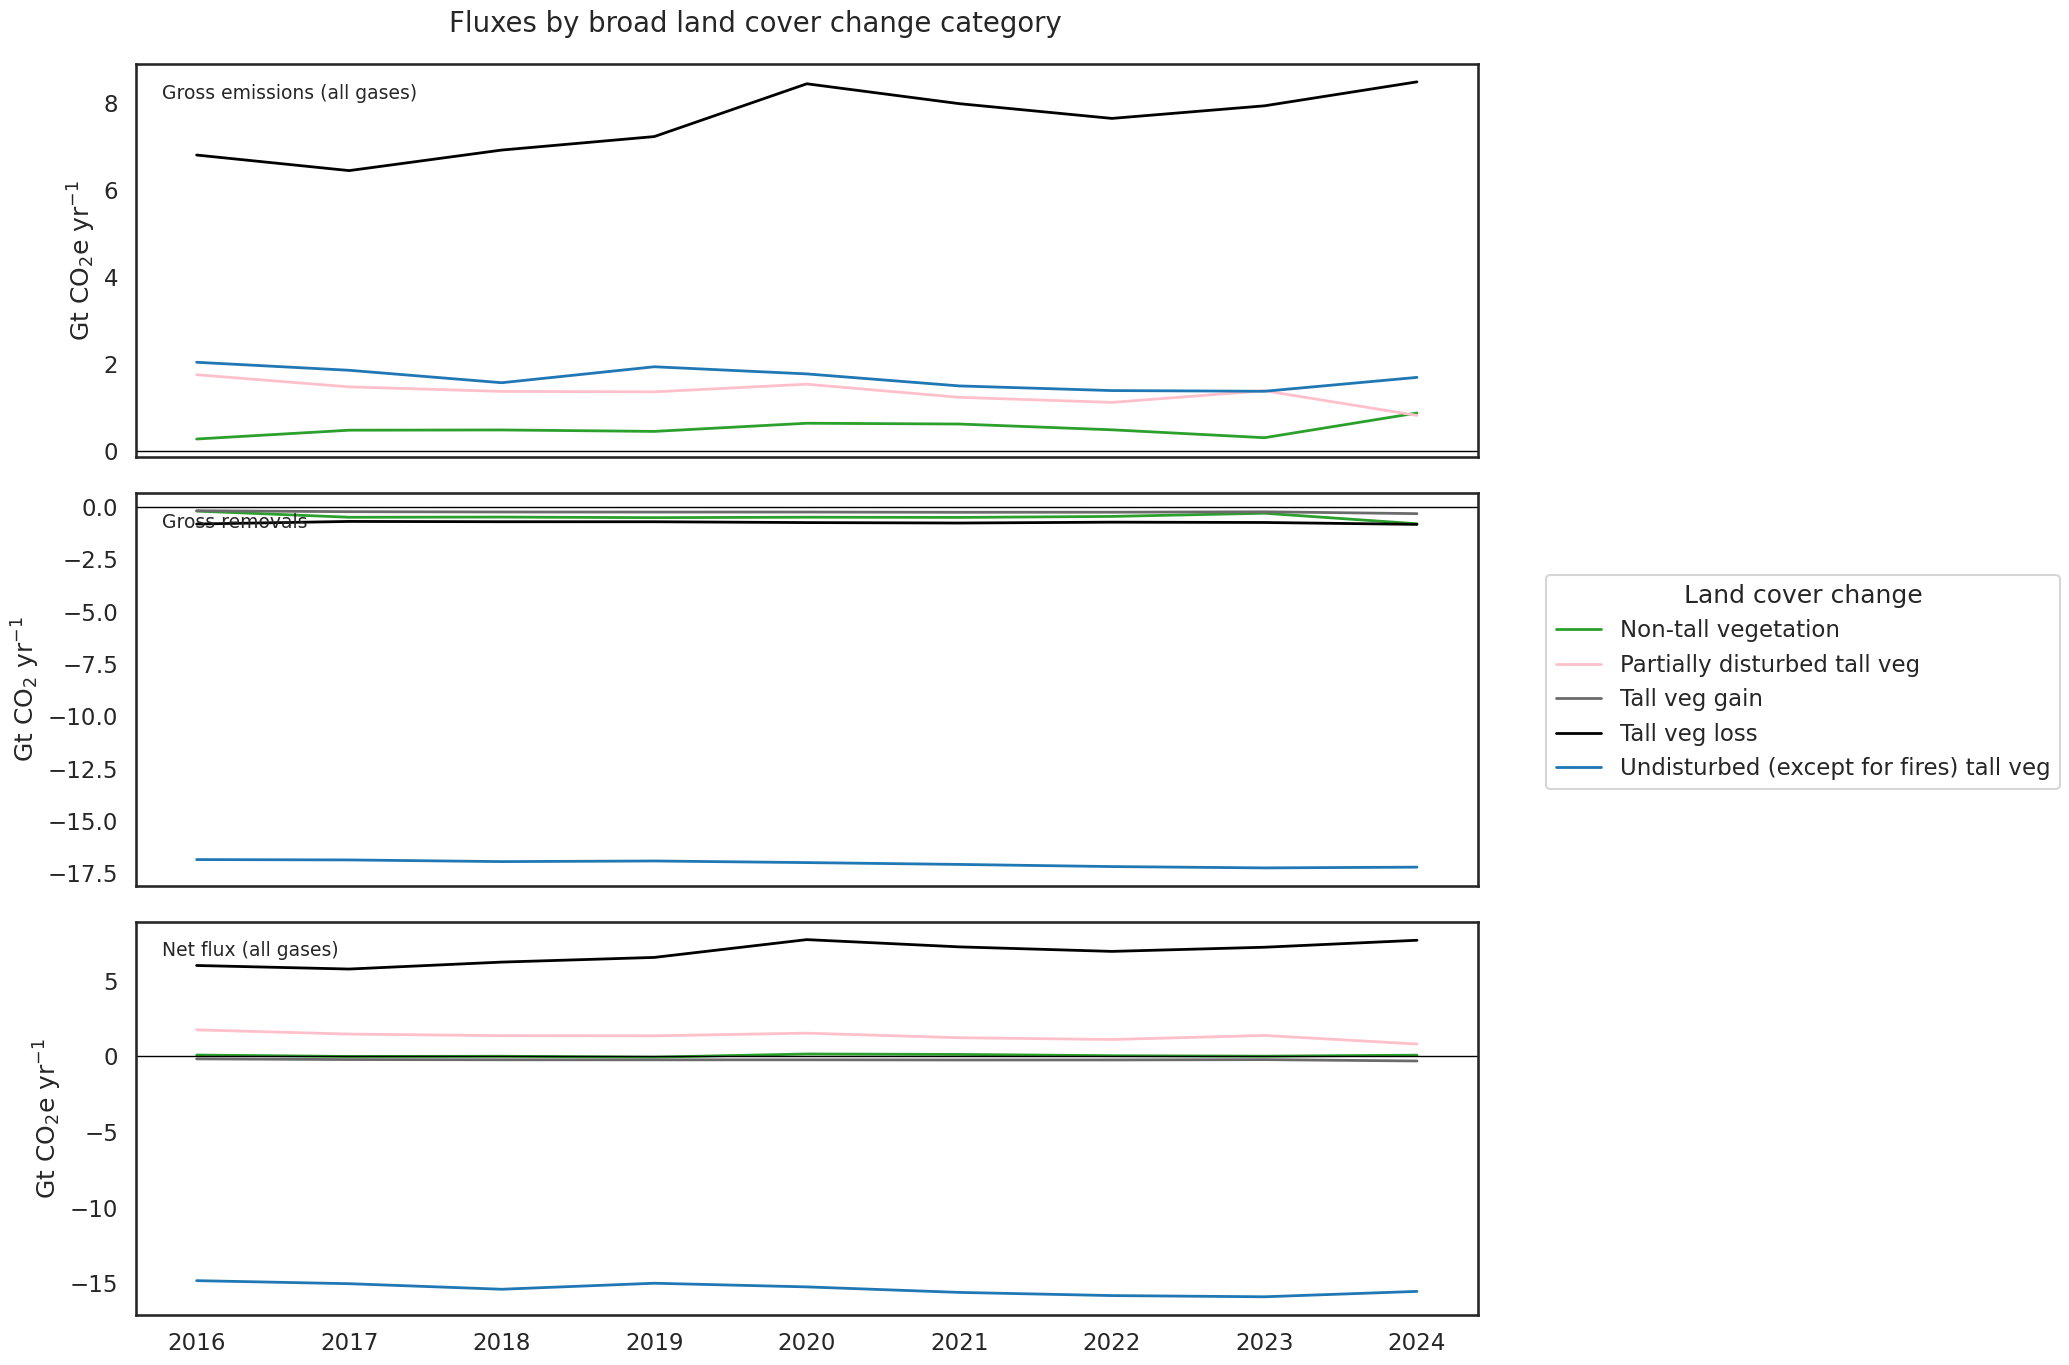

In [12]:
### Global emissions, removals, net flux timeseries by 4 landcover change categories (panel per flux)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69a5f52d-4db0-832e-8a7e-ee14ee9ac9d0

# ---- Setup ----
context_to_analyze = 'land_state_detailed_class'

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(15, 14),
    sharex=True
)

# Palette for detailed classes 
# detailed_class_palette = {
#     "Tall veg loss": "#000000",                     # black
#     "Tall veg gain": "#999999",                     # ?
#     "Partially disturbed tall veg": "#d62728",      # red
#     "Undisturbed (except for fires) tall veg": "#1f77b4",  # blue
#     "Stable short veg": "#2ca02c",                  # green
#     "Short veg loss": "#8c564b",                    # brown
#     "Short veg gain": "#111111",                    # ?
#     "Stable cropland": "#9467bd",                   # purple
#     "Cropland gain": "#ff7f0e",                     # orange
#     "Cropland loss": "#7f7f7f",                     # gray
# }

# Palette for detailed classes with 
detailed_class_palette = {
    "Tall veg loss": "#000000",                     # black
    "Tall veg gain": "#6b6b6b",                     # dark gray
    "Partially disturbed tall veg": "#FFC0CB",      # pink
    "Undisturbed (except for fires) tall veg": "#1f77b4",  # blue
    "Non-tall vegetation": "#2ca02c",               # green
}

panel_labels = [
    gross_emis_all_gases_legend,
    gross_removals_legend,
    net_flux_all_gases_legend
]

df_fig = df_graphs.copy()

# Patterns
emis_pattern = cn.gross_emis_all_C_pools_all_gases_pattern
remov_pattern = cn.gross_removals_all_C_pools_pattern
net_pattern = cn.net_flux_all_C_pools_all_gases_pattern

# ---- Aggregate first ----
df_emis = aggregate_layer(df_fig, emis_pattern)
df_remov = aggregate_layer(df_fig, remov_pattern)
df_net = aggregate_layer(df_fig, net_pattern)

# ---- Map to interpretable labels ----
df_emis[context_to_analyze] = df_emis[context_to_analyze].map(detailed_class_dict)
df_remov[context_to_analyze] = df_remov[context_to_analyze].map(detailed_class_dict)
df_net[context_to_analyze] = df_net[context_to_analyze].map(detailed_class_dict)

# ---- Collapse to tall vs other ----
def collapse_to_tall_vs_other(df):
    df = df.copy()
    df[context_to_analyze] = df[context_to_analyze].apply(
        lambda x: x if x in tall_veg_change_type_classes else "Non-tall vegetation"
    )
    return df

df_emis = collapse_to_tall_vs_other(df_emis)
df_remov = collapse_to_tall_vs_other(df_remov)
df_net = collapse_to_tall_vs_other(df_net)

# ---- Reaggregate after collapsing ----
def reaggregate(df):
    return (
        df.groupby([context_to_analyze, "year"], as_index=False)
          .agg({"value_Gt": "sum"})
    )

df_emis = reaggregate(df_emis)
df_remov = reaggregate(df_remov)
df_net = reaggregate(df_net)


# ---- Panel 1 ----
sns.lineplot(
    data=df_emis,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[0],
    linewidth=2,
    legend=False,
    palette=detailed_class_palette
)

axes[0].axhline(0, color="black", linewidth=1)
axes[0].grid(False)
axes[0].set_ylabel("Gt CO$_2$e yr$^{-1}$")

axes[0].text(
    0.02, 0.95,
    panel_labels[0],
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 2 ----
sns.lineplot(
    data=df_remov,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[1],
    linewidth=2,
    legend=False,
    palette=detailed_class_palette
)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].grid(False)
axes[1].set_ylabel("Gt CO$_2$ yr$^{-1}$")

axes[1].text(
    0.02, 0.95,
    panel_labels[1],
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 3 ----
sns.lineplot(
    data=df_net,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[2],
    linewidth=2,
    legend=True,
    palette=detailed_class_palette
)

axes[2].axhline(0, color="black", linewidth=1)
axes[2].grid(False)
axes[2].set_ylabel("Gt CO$_2$e yr$^{-1}$")
axes[2].set_xlabel(None)

axes[2].text(
    0.02, 0.95,
    panel_labels[2],
    transform=axes[2].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Single legend outside right ----
handles, labels = axes[2].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Land cover change",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

axes[2].legend().remove()

fig.suptitle(
    "Fluxes by broad land cover change category",
    fontsize=plt.rcParams["axes.titlesize"] * 1.1,
    y=0.98
)

plt.tight_layout()
plt.show()

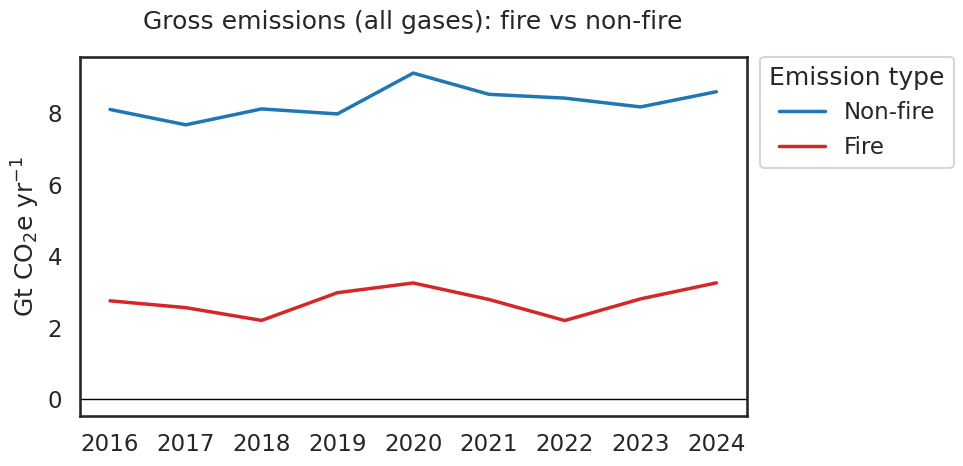

In [13]:
### Global gross emissions timeseries by fire vs. non-fire (single panel)

# ---- Setup ----
context_to_analyze = "land_state_node"

df_fig = df_graphs.copy()

# Filter to gross emissions (all gases)
df_emis = df_fig[
    df_fig["analysis_layer"] == cn.gross_emis_all_C_pools_all_gases_pattern
].copy()

# ---- Reclassify fire vs non-fire BEFORE aggregation ----
df_emis["fire_class"] = df_emis[context_to_analyze].astype(str).apply(
    lambda x: "Fire" if re.search(r"9(0*)$", x) else "Non-fire"
)

# ---- Aggregate ----
df_emis_ts = (
    df_emis
    .groupby(["fire_class", "year"], as_index=False)
    .agg({"value": "sum"})
)

df_emis_ts["value_Gt"] = df_emis_ts["value"] / 1e9

plt.figure(figsize=(10, 5))

palette = {
    "Fire": "#d62728",      # red
    "Non-fire": "#1f77b4",  # blue
}

hue_order = ["Non-fire", "Fire"]

ax = sns.lineplot(
    data=df_emis_ts,
    x="year",
    y="value_Gt",
    hue="fire_class",
    hue_order=hue_order,
    palette=palette,
    linewidth=2.5
)

ax.axhline(0, color="black", linewidth=1)
ax.grid(False)

ax.set_xlabel(None)
ax.set_ylabel("Gt CO$_2$e yr$^{-1}$")
ax.set_title("Gross emissions (all gases): fire vs non-fire", pad=20)

ax.legend(
    title="Emission type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

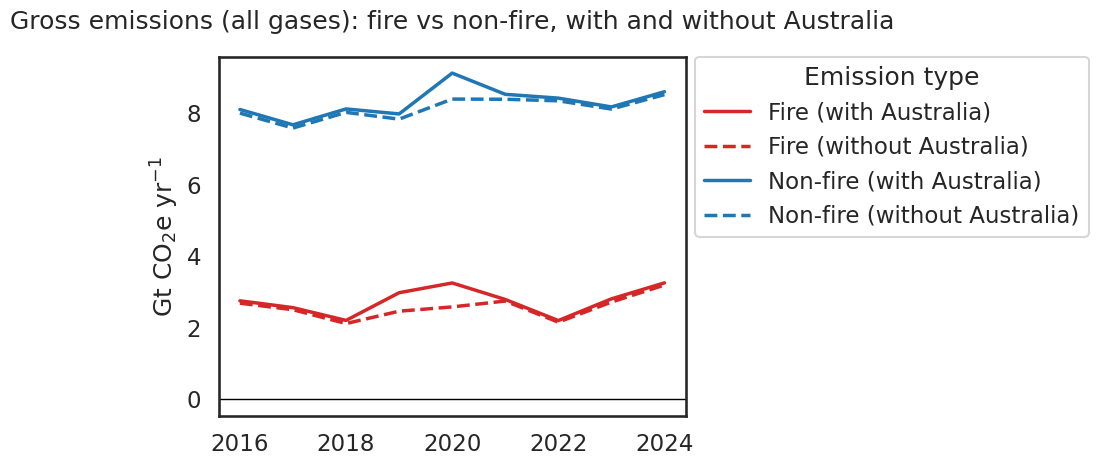

In [25]:
### Global gross emissions timeseries by fire vs. non-fire, with and without Australia (single panel)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69af7065-2604-832e-88b8-31d45c1938c0

# ---- Setup ----
context_to_analyze = "land_state_node"

df_fig = df_graphs.copy()

# Filter to gross emissions (all gases)
df_emis = df_fig[df_fig["analysis_layer"] == cn.gross_emis_all_C_pools_all_gases_pattern].copy()

# ---- Reclassify fire vs non-fire BEFORE aggregation ----
df_emis["fire_class"] = df_emis[context_to_analyze].astype(str).apply(
    lambda x: "Fire" if re.search(r"9(0*)$", x) else "Non-fire"
)

# ---- Flag Australia vs non-Australia ----
df_emis["Australia_group"] = np.where(
    df_emis["country_name"] == "Australia",
    "with Australia",
    "without Australia"
)

# ---- Aggregate WITH Australia ----
df_with_Australia = (
    df_emis
    .groupby(["fire_class", "year"], as_index=False)
    .agg({"value": "sum"})
)
df_with_Australia["Australia_group"] = "with Australia"

# ---- Aggregate WITHOUT Australia ----
df_without_Australia = (
    df_emis[df_emis["country_name"] != "Australia"]
    .groupby(["fire_class", "year"], as_index=False)
    .agg({"value": "sum"})
)
df_without_Australia["Australia_group"] = "without Australia"

# Combine
df_emis_ts = pd.concat([df_with_Australia, df_without_Australia], ignore_index=True)

# Convert to Gt
df_emis_ts["value_Gt"] = df_emis_ts["value"] / 1e9

# Create combined plotting label
df_emis_ts["series"] = df_emis_ts["fire_class"] + " (" + df_emis_ts["Australia_group"] + ")"

plt.figure(figsize=(10, 5))

palette = {
    "Fire": "#d62728",
    "Non-fire": "#1f77b4",
}

linestyle_map = {
    "with Australia": "-",
    "without Australia": "--"
}

ax = plt.gca()

# Plot each line separately to control linestyle
for (fire, Australia), sub in df_emis_ts.groupby(["fire_class", "Australia_group"]):

    ax.plot(
        sub["year"],
        sub["value_Gt"],
        color=palette[fire],
        linestyle=linestyle_map[Australia],
        linewidth=2.5,
        label=f"{fire} ({Australia})"
    )

ax.axhline(0, color="black", linewidth=1)
ax.grid(False)

ax.set_xlabel(None)
ax.set_ylabel("Gt CO$_2$e yr$^{-1}$")
ax.set_title("Gross emissions (all gases): fire vs non-fire, with and without Australia", pad=20)

ax.legend(
    title="Emission type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

['Albania', 'Algeria', 'Angola', 'Argentina', 'Australia', 'Austria', 'Azerbaijan', 'Bangladesh', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Cambodia', 'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cuba', 'Czechia', 'Côte d Ivoire', 'DR Congo', 'Dominican Republic', 'East Timor', 'Ecuador', 'El Salvador', 'Equatorial Guinea', 'Estonia', 'Ethiopia', 'Fiji', 'Finland', 'France', 'French Guiana', 'Gabon', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Hungary', 'India', 'Indonesia', 'Iran', 'Italy', 'Japan', 'Kazakhstan', 'Kenya', 'Korea', 'Korea (the Democratic Peoples Republic of)', 'Laos', 'Latvia', 'Liberia', 'Lithuania', 'Madagascar', 'Malawi', 'Malaysia', 'Mali', 'Mexico', 'Mongolia', 'Morocco', 'Mozambique', 'Myanmar', 'Namibia', 'Nepal', 'New Caledonia', 

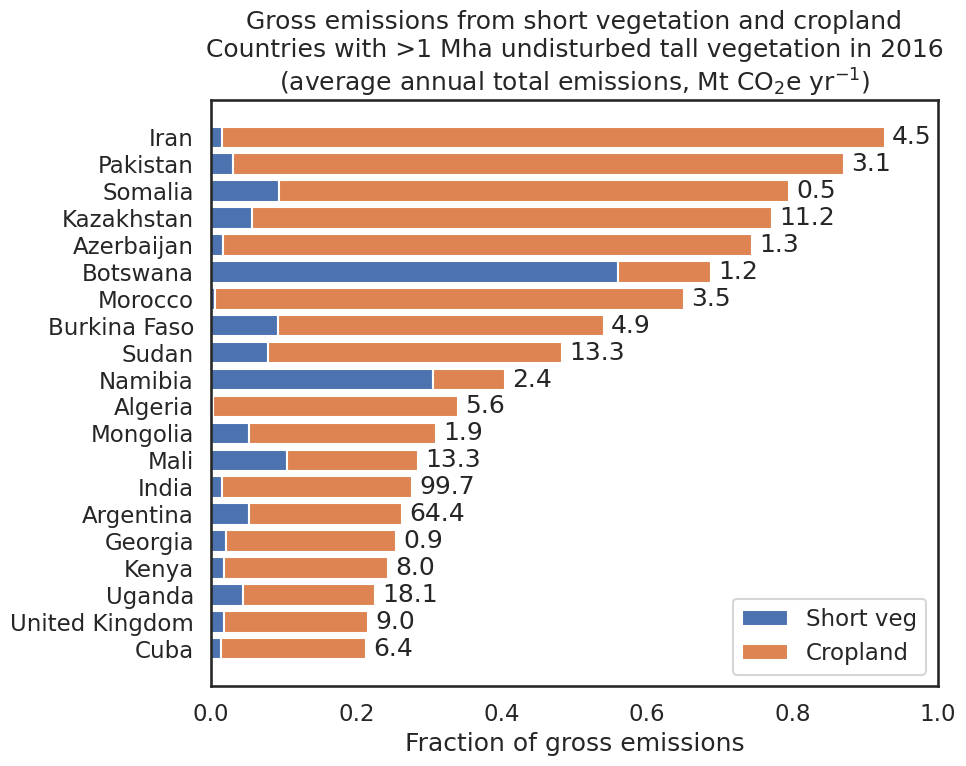

In [14]:
### Countries with >1 Mha "non-disturbed tall veg" in 2016 with the highest fraction of emissions from non-tall vegetation

## Determine which countries have enough forest area

min_area = 1_000_000

top_n = 20  # Number of countries to plot

# New df for determining countries with large forest area
df_large_forest_area = df_graphs.copy()

# Restrict to undisturbed tall veg in 2016 (as proxy for forest area)
df_large_forest_area_2016 = df_large_forest_area[
    (df_large_forest_area["year"] == 2016) &
    (df_large_forest_area["land_state_detailed_class"] == "tree_tree_undisturbed") &
    (df_large_forest_area["analysis_layer"] == cn.net_flux_all_C_pools_all_gases_pattern)  # Need to use just one analysis layer to not double-count areas
]

# # Print table for a select country to use for QC
# to_exp = df_large_forest_area[
#     # (df_large_forest_area["year"] == 2016) &
#     (df_large_forest_area["country_name"] == "Iran") &
#     (df_large_forest_area["analysis_layer"] == cn.gross_emis_all_C_pools_all_gases_pattern)  # Need to use just one analysis layer to not double-count areas
# ]
# to_exp.to_csv("/mnt/c/GIS/test2.csv")

# Sums area for 2016 across all remaining contextual layer combinations
country_tree_tree_area_2016_total = df_large_forest_area_2016.groupby("country_name", as_index=False)['area_ha'].sum()
# print(country_tree_tree_area_2016_total.sort_values("area_ha", ascending=False).head(50))

# Apply 1 Mha threshold
eligible_countries = country_tree_tree_area_2016_total.loc[country_tree_tree_area_2016_total["area_ha"] > min_area, "country_name"].tolist()
print(eligible_countries)


## Calculate fraction of emissions from tall vegetation

# Filter to gross emissions (all gases)
df_emis = df_graphs[
    df_graphs["analysis_layer"] == cn.gross_emis_all_C_pools_all_gases_pattern
].copy()

df_emis["veg_cat"] = np.select(
    [
        df_emis["land_state_detailed_class"].str.contains("tree", case=False, na=False),
        df_emis["land_state_detailed_class"].str.contains("crop", case=False, na=False),
        df_emis["land_state_detailed_class"].str.contains("short", case=False, na=False),
    ],
    [
        "Tall veg",
        "Cropland",
        "Short veg",
    ],
    default="Other"
)

# Sum across ALL YEARS by country and veg group
country_cat = (
    df_emis[df_emis["country_name"].isin(eligible_countries)]
    .groupby(["country_name", "veg_cat"], as_index=False)["value"]
    .sum()
)
# print(country_cat)

# Pivot to wide format
country_wide = country_cat.pivot_table(
    index="country_name",
    columns="veg_cat",
    values="value",
    fill_value=0
)
country_wide.columns.name = None
country_wide = country_wide.reset_index()
# print(country_wide)

# Compute total and fractions
country_wide["total_Mg_all_years"] = country_wide[["Tall veg", "Short veg", "Cropland"]].sum(axis=1)
country_wide["total_Mt_per_year"] = country_wide["total_Mg_all_years"]/years/10**6
country_wide["frac_tall"] = np.where(country_wide["total_Mg_all_years"] > 0, country_wide["Tall veg"] / country_wide["total_Mg_all_years"], np.nan)
country_wide["frac_short"] = np.where(country_wide["total_Mg_all_years"] > 0, country_wide["Short veg"] / country_wide["total_Mg_all_years"], np.nan)
country_wide["frac_crop"] = np.where(country_wide["total_Mg_all_years"] > 0, country_wide["Cropland"] / country_wide["total_Mg_all_years"], np.nan)
country_wide["fraction_non_tall"] = (country_wide["frac_short"] + country_wide["frac_crop"])
# print(country_wide)

# Sort highest to lowest
country_ranked = country_wide.sort_values(
    "fraction_non_tall",
    ascending=False
)
# print(country_ranked)

# Limit results to countries with >1 Mha undisturbed tall veg in 2016
country_ranked_eligible = (
    country_ranked[
        country_ranked["country_name"].isin(eligible_countries)
    ]
    .sort_values("fraction_non_tall", ascending=False)
)
print(country_ranked_eligible.head(top_n))


## Plot as stacked horizontal bar graph

df_plot = country_ranked_eligible.head(top_n).copy()
df_plot = df_plot.reset_index()
countries = df_plot["country_name"].tolist()

fig, ax = plt.subplots(figsize=(10, 8))

y = np.arange(len(countries))

# Only non-tall fractions
short = df_plot["frac_short"].values
crop = df_plot["frac_crop"].values
totals_Mt_yr = df_plot["total_Mt_per_year"].values

# Stack from zero
ax.barh(y, short, label="Short veg")
ax.barh(y, crop, left=short, label="Cropland")

ax.set_yticks(y)
ax.set_yticklabels(countries)
ax.invert_yaxis()

ax.set_xlim(0, 1)
ax.set_xlabel("Fraction of gross emissions")
ax.set_title(
    "Gross emissions from short vegetation and cropland\n"
    f"Countries with >{min_area/1e6:.0f} Mha undisturbed tall vegetation in 2016\n"
    "(average annual total emissions, Mt CO$_2$e yr$^{-1}$)"
)

for i, row in df_plot.iterrows():
    ax.text(
        row["fraction_non_tall"] + 0.01,   # small offset to right of bar
        list(df_plot.index).index(i),      # y-position
        f"{row.total_Mt_per_year:.1f}",
        va="center"
    )

ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

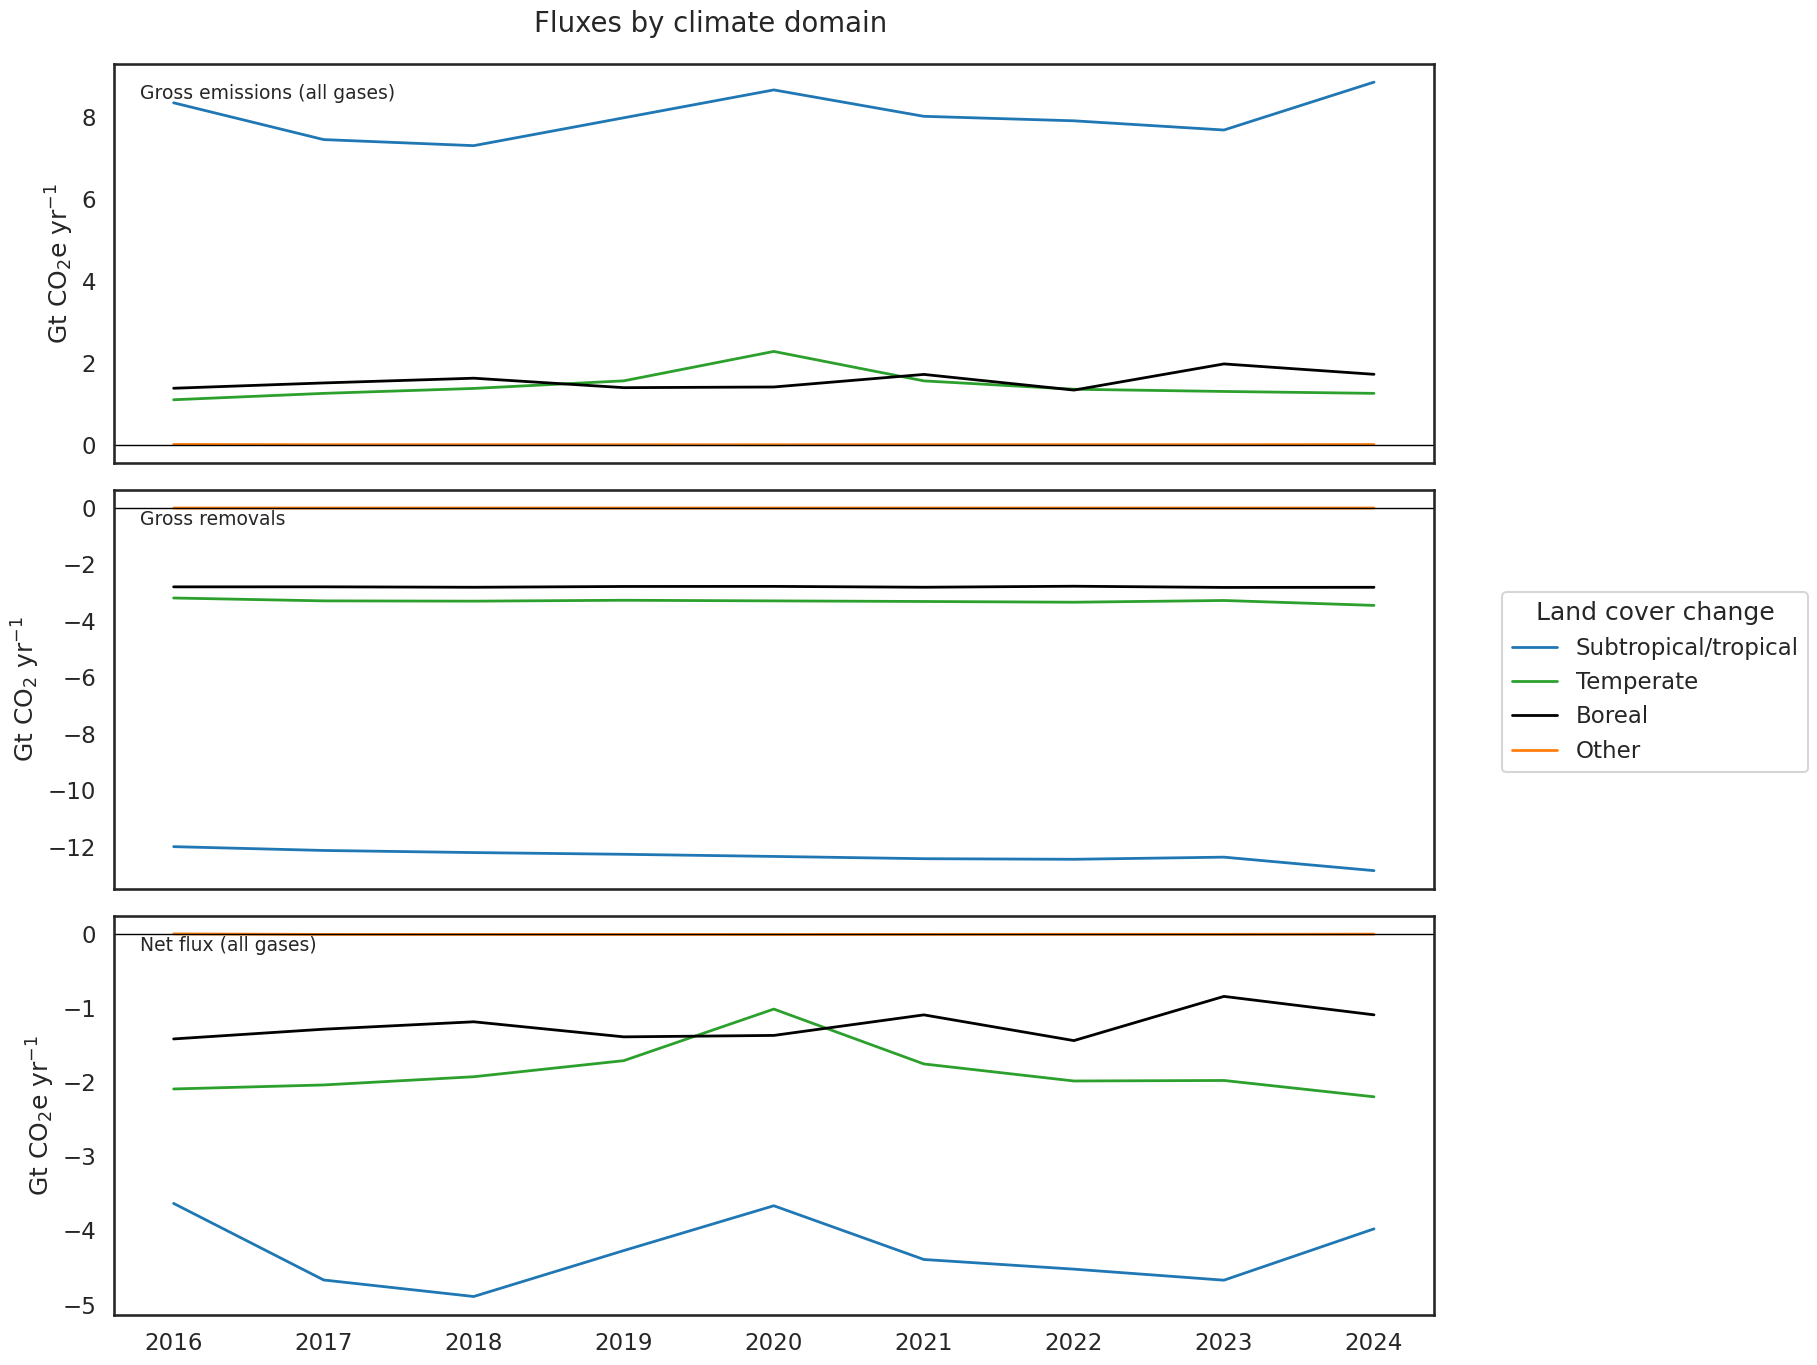

In [15]:
### Global emissions, removals, net flux timeseries by climate domain (panel per flux)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69a5f52d-4db0-832e-8a7e-ee14ee9ac9d0
### and https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69a88942-4cbc-8333-98ab-2c444cc044bd

context_to_analyze = 'climate_domain'

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(15, 14),
    sharex=True
)

# Palette for classes
domain_palette = {
    "Boreal": "#000000",                     # black
    "Temperate": "#2ca02c",                    # green
    "Subtropical/tropical": "#1f77b4",     # blue
    "Other": "#ff7f0e"                     # orange
}

# Order of entries based on order of lines in emissions graph
desired_domain_order = [
    "Subtropical/tropical",
    "Temperate",
    "Boreal",
    "Other",
]

panel_labels = [
    gross_emis_all_gases_legend,
    gross_removals_legend,
    net_flux_all_gases_legend
]

df_fig = df_graphs.copy()

# 2) Classify ecozone names to climate domain
s = df_fig["continent_ecozone"]

df_fig["climate_domain"] = np.select(
    [
        s.str.contains("boreal", case=False, na=False) | s.str.contains("polar", case=False, na=False),
        s.str.contains("temperate", case=False, na=False),
        s.str.contains("tropical", case=False, na=False) | s.str.contains("subtropical", case=False, na=False),
    ],
    [
        "Boreal",
        "Temperate",
        "Subtropical/tropical",
    ],
    default="Other"
)
# print(df_fig)

# Patterns
emis_pattern = cn.gross_emis_all_C_pools_all_gases_pattern
remov_pattern = cn.gross_removals_all_C_pools_pattern
net_pattern = cn.net_flux_all_C_pools_all_gases_pattern

# ---- Aggregate first ----
df_emis = aggregate_layer(df_fig, emis_pattern)
df_remov = aggregate_layer(df_fig, remov_pattern)
df_net = aggregate_layer(df_fig, net_pattern)


# ---- Reaggregate after collapsing ----
def reaggregate(df):
    return (
        df.groupby([context_to_analyze, "year"], as_index=False)
          .agg({"value_Gt": "sum"})
    )

df_emis = reaggregate(df_emis)
df_remov = reaggregate(df_remov)
df_net = reaggregate(df_net)

# Defines order of legend entries
for df in [df_emis, df_remov, df_net]:
    df["climate_domain"] = pd.Categorical(
        df["climate_domain"],
        categories=desired_domain_order,
        ordered=True
    )


# ---- Panel 1 ----
sns.lineplot(
    data=df_emis,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    hue_order=desired_domain_order,
    ax=axes[0],
    linewidth=2,
    legend=False,
    palette=domain_palette
)

axes[0].axhline(0, color="black", linewidth=1)
axes[0].grid(False)
axes[0].set_ylabel("Gt CO$_2$e yr$^{-1}$")

axes[0].text(
    0.02, 0.95,
    panel_labels[0],
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 2 ----
sns.lineplot(
    data=df_remov,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    hue_order=desired_domain_order,
    ax=axes[1],
    linewidth=2,
    legend=False,
    palette=domain_palette
)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].grid(False)
axes[1].set_ylabel("Gt CO$_2$ yr$^{-1}$")

axes[1].text(
    0.02, 0.95,
    panel_labels[1],
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 3 ----
sns.lineplot(
    data=df_net,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    hue_order=desired_domain_order,
    ax=axes[2],
    linewidth=2,
    legend=True,
    palette=domain_palette
)

axes[2].axhline(0, color="black", linewidth=1)
axes[2].grid(False)
axes[2].set_ylabel("Gt CO$_2$e yr$^{-1}$")
axes[2].set_xlabel(None)

axes[2].text(
    0.02, 0.95,
    panel_labels[2],
    transform=axes[2].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Single legend outside right ----
handles, labels = axes[2].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Land cover change",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

axes[2].legend().remove()

fig.suptitle(
    "Fluxes by climate domain",
    fontsize=plt.rcParams["axes.titlesize"] * 1.1,
    y=0.98
)

plt.tight_layout()
plt.show()

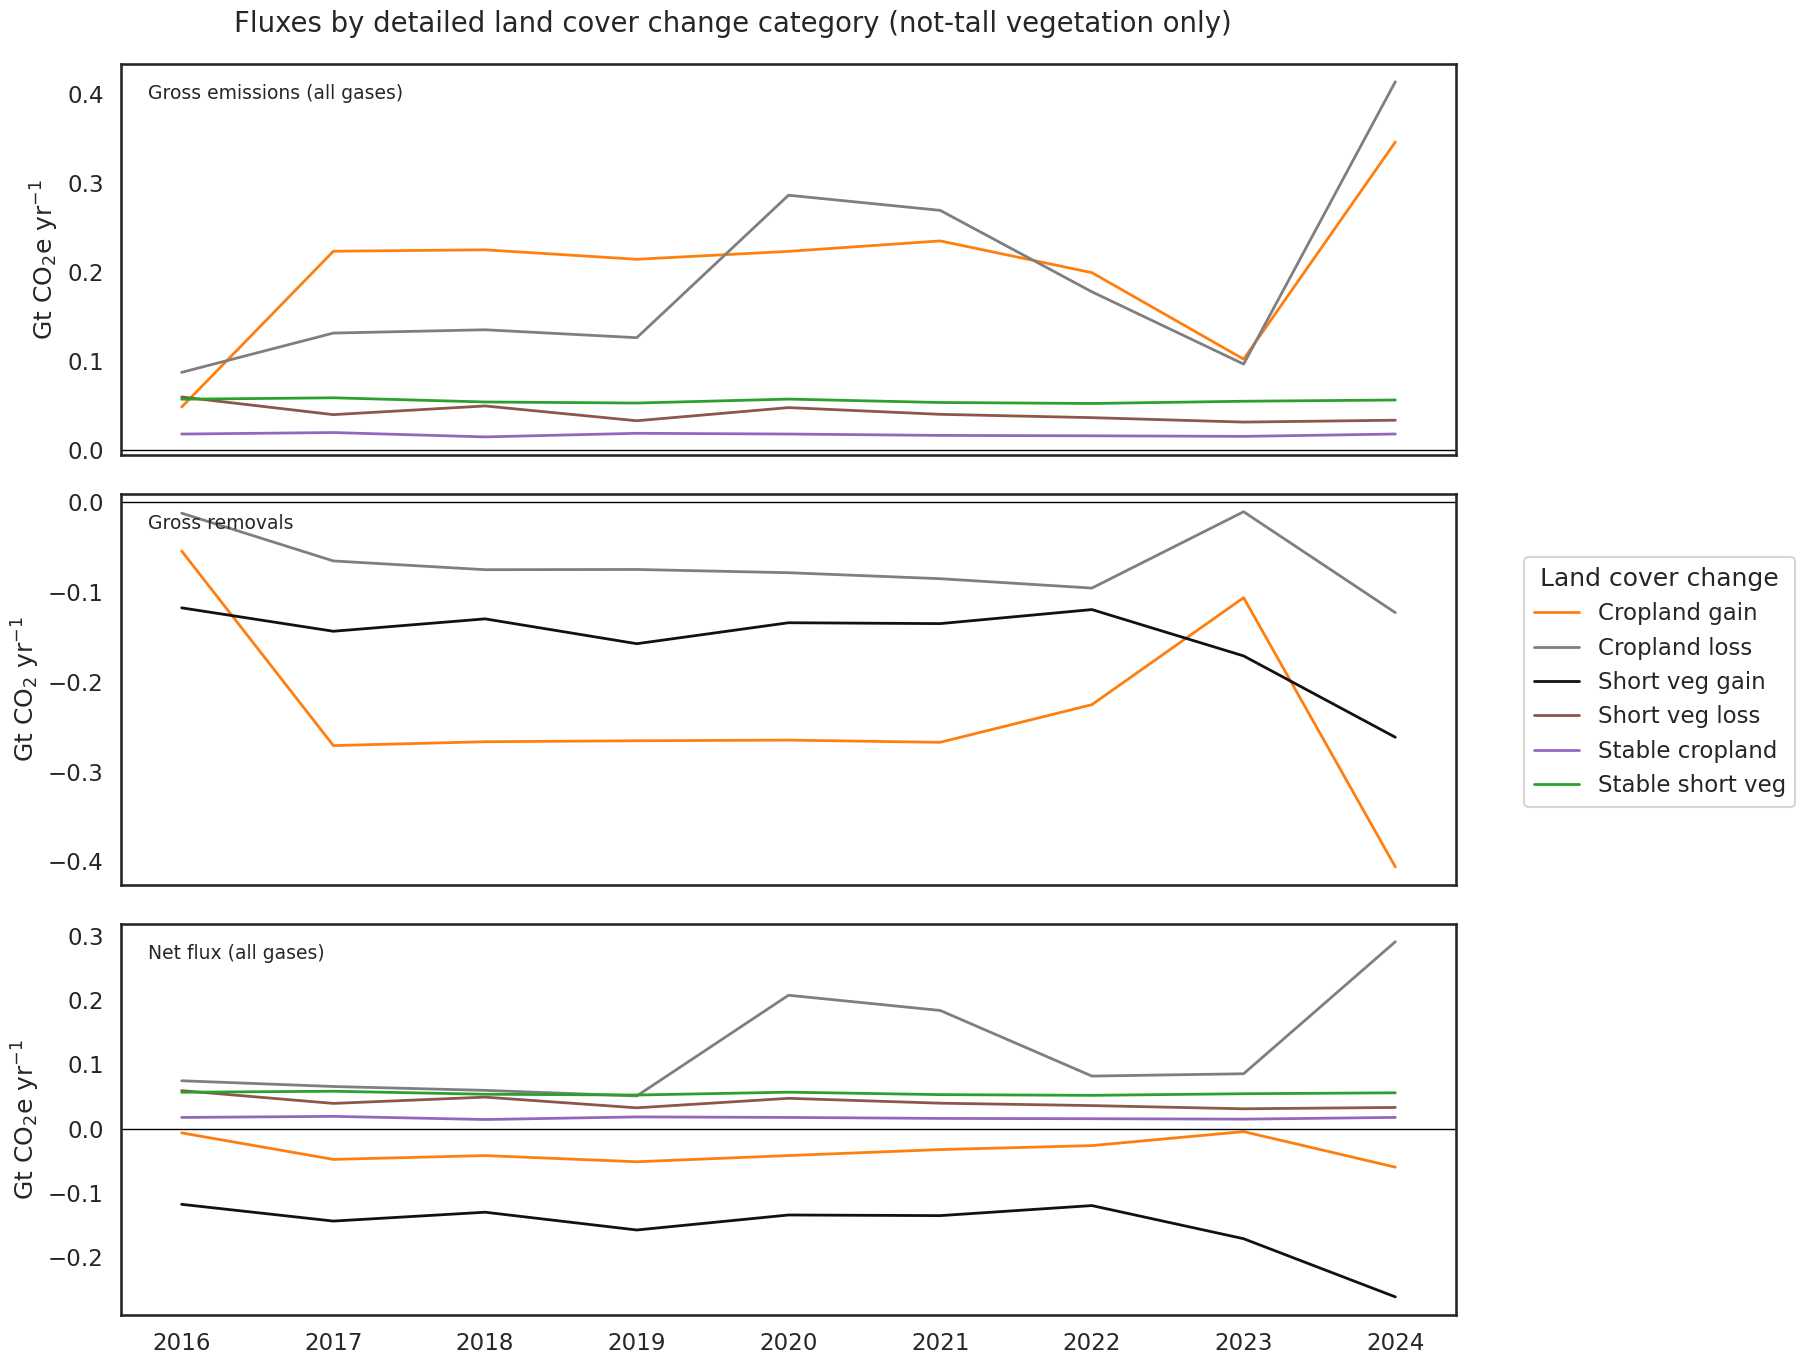

In [16]:
### Global emissions, removals, net flux timeseries by detailed non-tall vegetation landcover change categories (panel per flux)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69a5f52d-4db0-832e-8a7e-ee14ee9ac9d0
### and https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69aee45e-ce6c-8325-b1d0-a6c6b0e7ae2e

# ---- Setup ----
context_to_analyze = 'land_state_detailed_class'

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(15, 14),
    sharex=True
)

# Palette for detailed classes 
detailed_class_palette = {
    # "Tall veg loss": "#000000",                     # black
    # "Tall veg gain": "#999999",                     # ?
    # "Partially disturbed tall veg": "#d62728",      # red
    # "Undisturbed (except for fires) tall veg": "#1f77b4",  # blue
    "Stable short veg": "#2ca02c",                  # green
    "Short veg loss": "#8c564b",                    # brown
    "Short veg gain": "#111111",                    # ?
    "Stable cropland": "#9467bd",                   # purple
    "Cropland gain": "#ff7f0e",                     # orange
    "Cropland loss": "#7f7f7f",                     # gray
}

panel_labels = [
    gross_emis_all_gases_legend,
    gross_removals_legend,
    net_flux_all_gases_legend
]

df_fig = df_graphs.copy()

# Patterns
emis_pattern = cn.gross_emis_all_C_pools_all_gases_pattern
remov_pattern = cn.gross_removals_all_C_pools_pattern
net_pattern = cn.net_flux_all_C_pools_all_gases_pattern

# ---- Aggregate first ----
df_emis = aggregate_layer(df_fig, emis_pattern)
df_remov = aggregate_layer(df_fig, remov_pattern)
df_net = aggregate_layer(df_fig, net_pattern)

# ---- Map to interpretable labels ----
df_emis[context_to_analyze] = df_emis[context_to_analyze].map(detailed_class_dict)
df_remov[context_to_analyze] = df_remov[context_to_analyze].map(detailed_class_dict)
df_net[context_to_analyze] = df_net[context_to_analyze].map(detailed_class_dict)

# # ---- Remove specific category/ies ----
def drop_tall(df):
    return df[~df[context_to_analyze].str.contains("Tall veg", case=False, na=False)]

df_emis = drop_tall(df_emis)
df_remov = drop_tall(df_remov)
df_net = drop_tall(df_net)

# ---- Reaggregate after collapsing ----
def reaggregate(df):
    return (
        df.groupby([context_to_analyze, "year"], as_index=False)
          .agg({"value_Gt": "sum"})
    )

df_emis = reaggregate(df_emis)
df_remov = reaggregate(df_remov)
df_net = reaggregate(df_net)


# ---- Panel 1 ----
sns.lineplot(
    data=df_emis,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[0],
    linewidth=2,
    legend=False,
    palette=detailed_class_palette
)

axes[0].axhline(0, color="black", linewidth=1)
axes[0].grid(False)
axes[0].set_ylabel("Gt CO$_2$e yr$^{-1}$")

axes[0].text(
    0.02, 0.95,
    panel_labels[0],
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 2 ----
sns.lineplot(
    data=df_remov,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[1],
    linewidth=2,
    legend=False,
    palette=detailed_class_palette
)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].grid(False)
axes[1].set_ylabel("Gt CO$_2$ yr$^{-1}$")

axes[1].text(
    0.02, 0.95,
    panel_labels[1],
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 3 ----
sns.lineplot(
    data=df_net,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[2],
    linewidth=2,
    legend=True,
    palette=detailed_class_palette
)

axes[2].axhline(0, color="black", linewidth=1)
axes[2].grid(False)
axes[2].set_ylabel("Gt CO$_2$e yr$^{-1}$")
axes[2].set_xlabel(None)

axes[2].text(
    0.02, 0.95,
    panel_labels[2],
    transform=axes[2].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Single legend outside right ----
handles, labels = axes[2].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Land cover change",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

axes[2].legend().remove()

fig.suptitle(
    "Fluxes by detailed land cover change category (not-tall vegetation only)",
    fontsize=plt.rcParams["axes.titlesize"] * 1.1,
    y=0.98
)

plt.tight_layout()
plt.show()

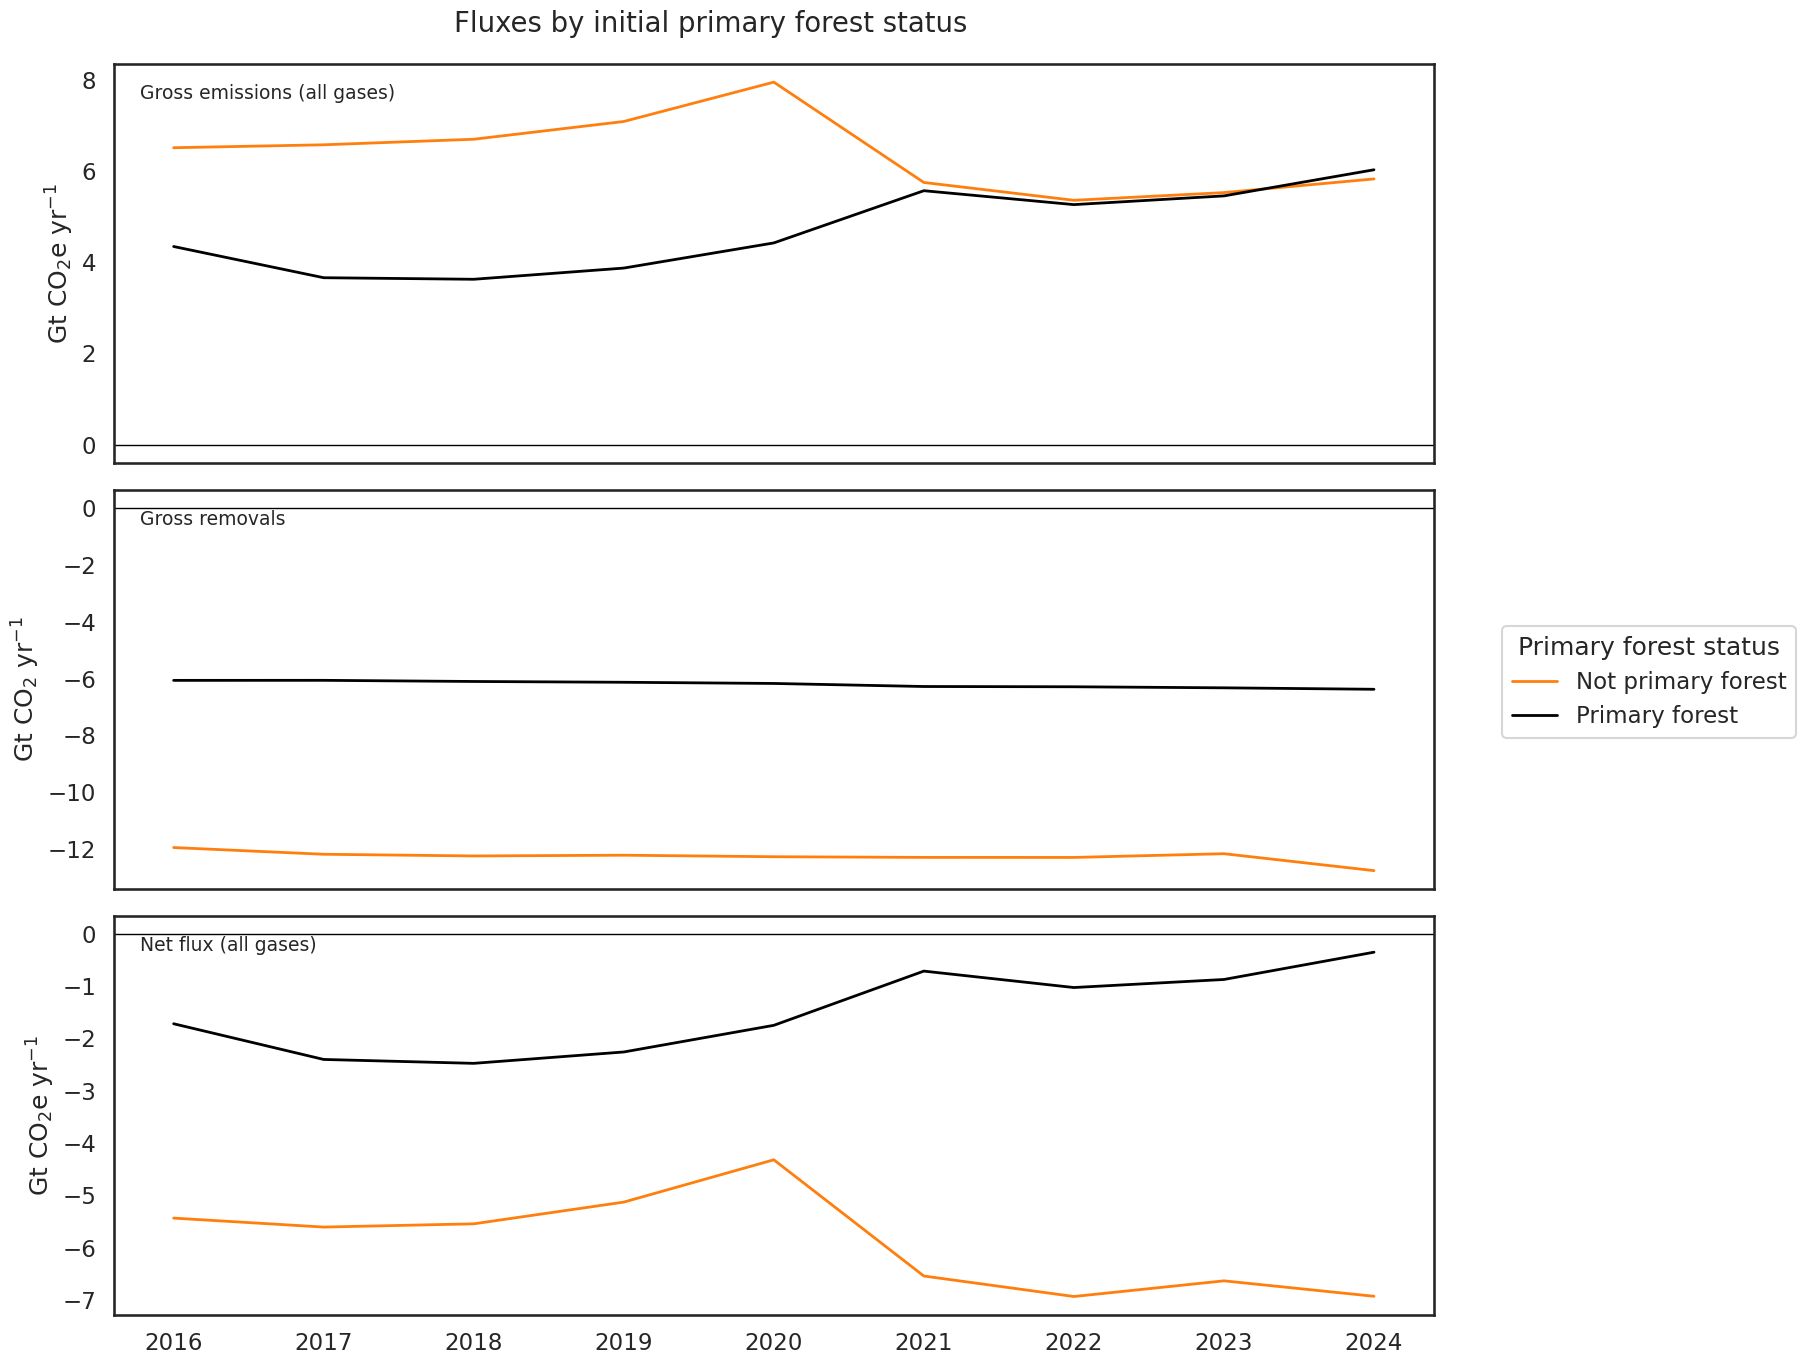

In [17]:
### Global emissions, removals, net flux timeseries by starting primary forest classification (panel per flux)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69a5f52d-4db0-832e-8a7e-ee14ee9ac9d0

# ---- Setup ----
context_to_analyze = 'starting_composite_primary_forest'

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(15, 14),
    sharex=True
)

# Palette for detailed classes 
primary_forest_palette = {
    "Primary forest": "#000000",                     # black
    "Not primary forest": "#ff7f0e"                  # orange
}

panel_labels = [
    gross_emis_all_gases_legend,
    gross_removals_legend,
    net_flux_all_gases_legend
]

df_fig = df_graphs.copy()

# Patterns
emis_pattern = cn.gross_emis_all_C_pools_all_gases_pattern
remov_pattern = cn.gross_removals_all_C_pools_pattern
net_pattern = cn.net_flux_all_C_pools_all_gases_pattern

# ---- Aggregate first ----
df_emis = aggregate_layer(df_fig, emis_pattern)
df_remov = aggregate_layer(df_fig, remov_pattern)
df_net = aggregate_layer(df_fig, net_pattern)

# ---- Map to interpretable labels ----
df_emis[context_to_analyze] = df_emis[context_to_analyze].map(primary_forest_dict)
df_remov[context_to_analyze] = df_remov[context_to_analyze].map(primary_forest_dict)
df_net[context_to_analyze] = df_net[context_to_analyze].map(primary_forest_dict)

# ---- Reaggregate after collapsing ----
def reaggregate(df):
    return (
        df.groupby([context_to_analyze, "year"], as_index=False)
          .agg({"value_Gt": "sum"})
    )

df_emis = reaggregate(df_emis)
df_remov = reaggregate(df_remov)
df_net = reaggregate(df_net)


# ---- Panel 1 ----
sns.lineplot(
    data=df_emis,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[0],
    linewidth=2,
    legend=False,
    palette=primary_forest_palette
)

axes[0].axhline(0, color="black", linewidth=1)
axes[0].grid(False)
axes[0].set_ylabel("Gt CO$_2$e yr$^{-1}$")

axes[0].text(
    0.02, 0.95,
    panel_labels[0],
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 2 ----
sns.lineplot(
    data=df_remov,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[1],
    linewidth=2,
    legend=False,
    palette=primary_forest_palette
)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].grid(False)
axes[1].set_ylabel("Gt CO$_2$ yr$^{-1}$")

axes[1].text(
    0.02, 0.95,
    panel_labels[1],
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 3 ----
sns.lineplot(
    data=df_net,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[2],
    linewidth=2,
    legend=True,
    palette=primary_forest_palette
)

axes[2].axhline(0, color="black", linewidth=1)
axes[2].grid(False)
axes[2].set_ylabel("Gt CO$_2$e yr$^{-1}$")
axes[2].set_xlabel(None)

axes[2].text(
    0.02, 0.95,
    panel_labels[2],
    transform=axes[2].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Single legend outside right ----
handles, labels = axes[2].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Primary forest status",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

axes[2].legend().remove()

fig.suptitle(
    "Fluxes by initial primary forest status",
    fontsize=plt.rcParams["axes.titlesize"] * 1.1,
    y=0.98
)

plt.tight_layout()
plt.show()

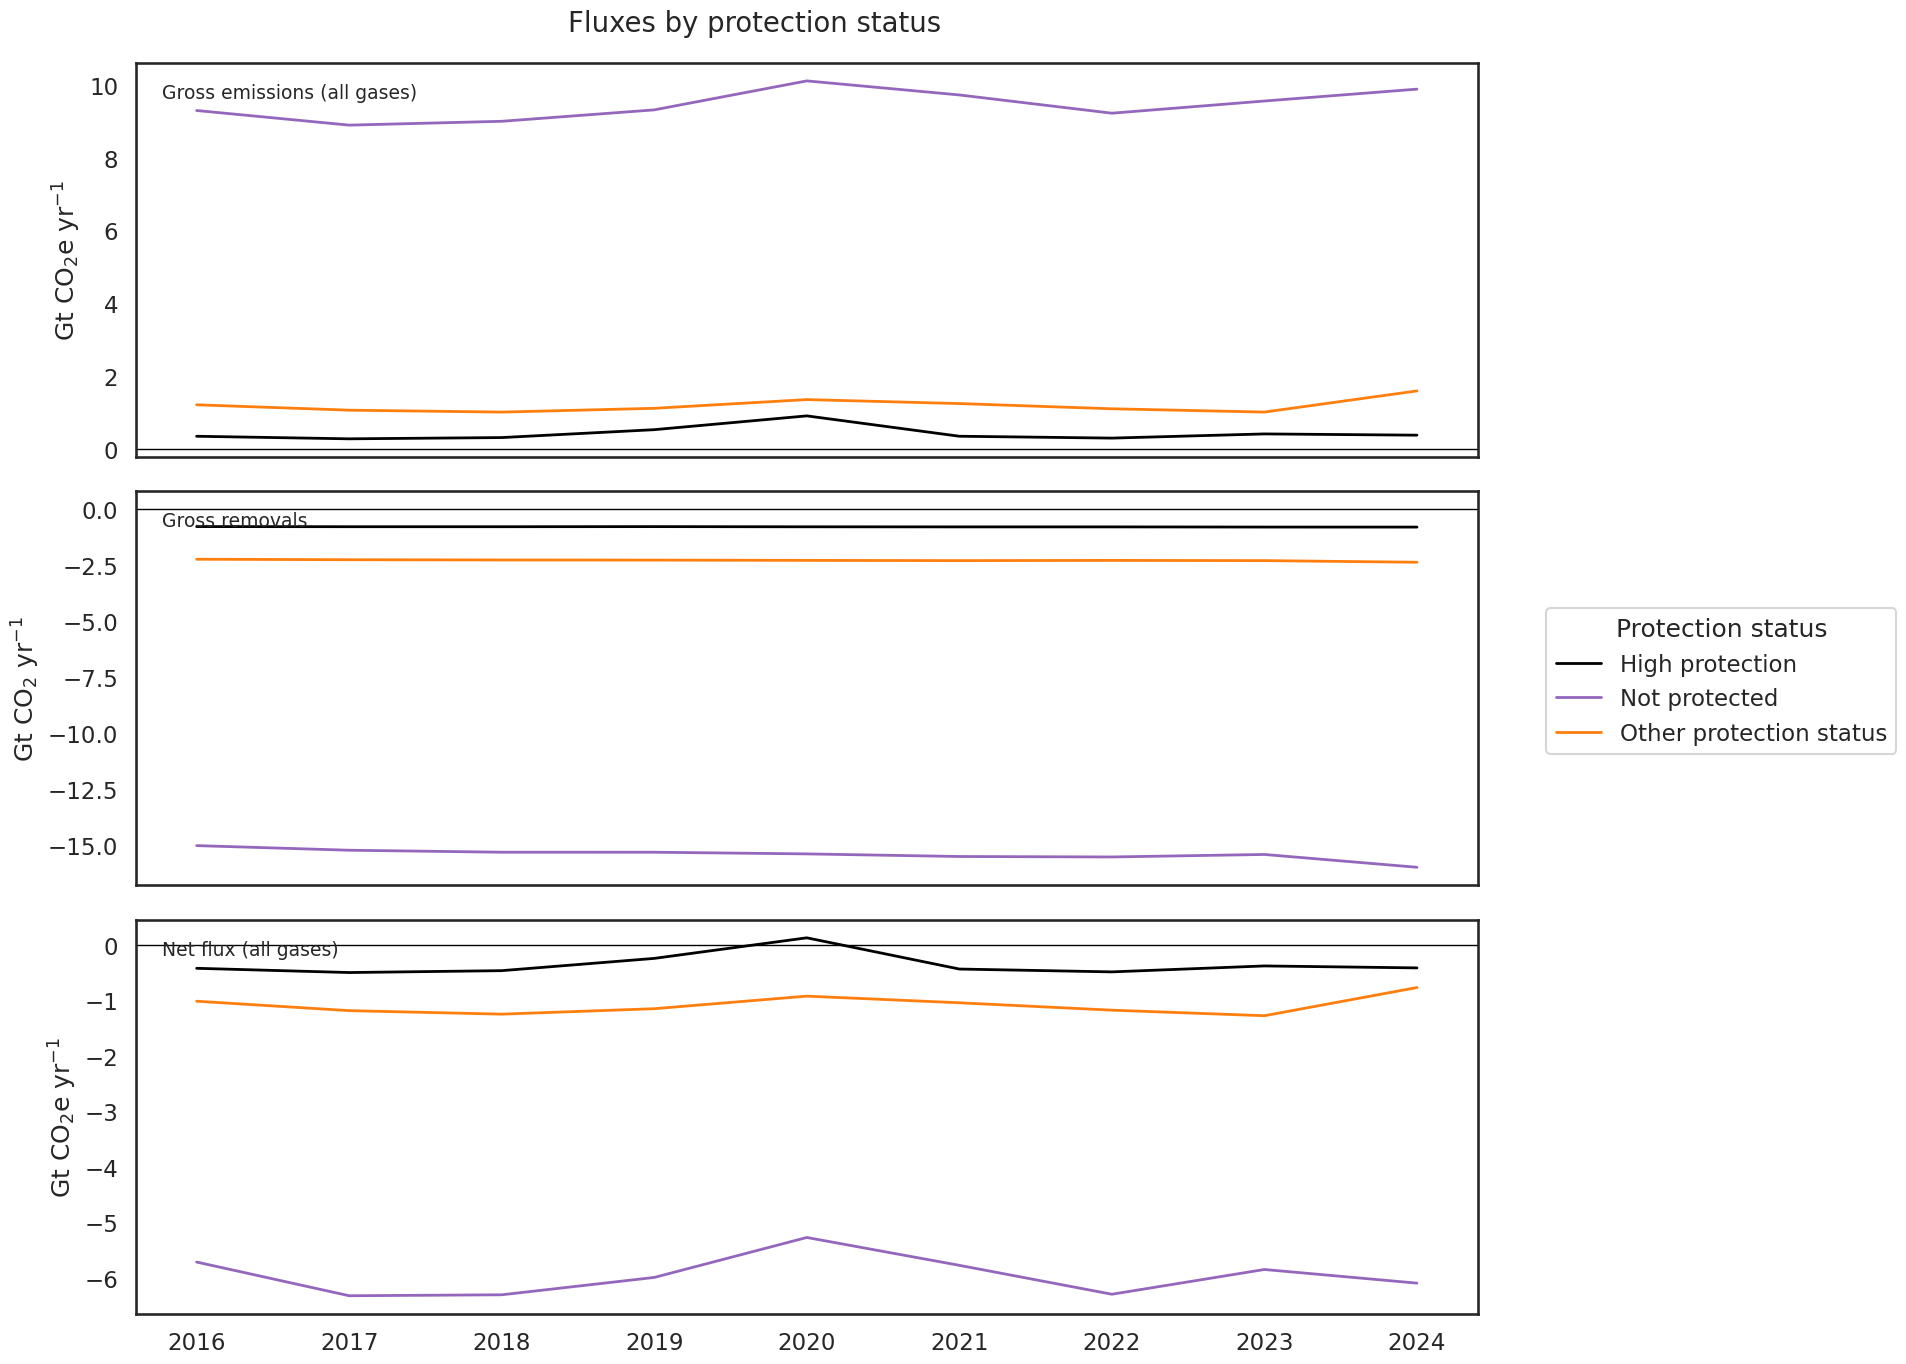

In [20]:
### Global emissions, removals, net flux timeseries by WDPA protection level (high vs. low vs. no status) (panel per flux)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69a5f52d-4db0-832e-8a7e-ee14ee9ac9d0

# ---- Setup ----
context_to_analyze = 'WDPA_high_protection'

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(15, 14),
    sharex=True
)

# Palette for detailed classes 
protection_palette = {
    "High protection": "#000000",                     # black
    "Other protection status": "#ff7f0e",                  # orange
    "Not protected": "#9467bd"                  # purple
}

panel_labels = [
    gross_emis_all_gases_legend,
    gross_removals_legend,
    net_flux_all_gases_legend
]

df_fig = df_graphs.copy()

# Patterns
emis_pattern = cn.gross_emis_all_C_pools_all_gases_pattern
remov_pattern = cn.gross_removals_all_C_pools_pattern
net_pattern = cn.net_flux_all_C_pools_all_gases_pattern

# ---- Aggregate first ----
df_emis = aggregate_layer(df_fig, emis_pattern)
df_remov = aggregate_layer(df_fig, remov_pattern)
df_net = aggregate_layer(df_fig, net_pattern)

# # ---- Map to interpretable labels ----
# df_emis[context_to_analyze] = df_emis[context_to_analyze].map(primary_forest_dict)
# df_remov[context_to_analyze] = df_remov[context_to_analyze].map(primary_forest_dict)
# df_net[context_to_analyze] = df_net[context_to_analyze].map(primary_forest_dict)

# ---- Reaggregate after collapsing ----
def reaggregate(df):
    return (
        df.groupby([context_to_analyze, "year"], as_index=False)
          .agg({"value_Gt": "sum"})
    )

df_emis = reaggregate(df_emis)
df_remov = reaggregate(df_remov)
df_net = reaggregate(df_net)


# ---- Panel 1 ----
sns.lineplot(
    data=df_emis,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[0],
    linewidth=2,
    legend=False,
    palette=protection_palette
)

axes[0].axhline(0, color="black", linewidth=1)
axes[0].grid(False)
axes[0].set_ylabel("Gt CO$_2$e yr$^{-1}$")

axes[0].text(
    0.02, 0.95,
    panel_labels[0],
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 2 ----
sns.lineplot(
    data=df_remov,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[1],
    linewidth=2,
    legend=False,
    palette=protection_palette
)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].grid(False)
axes[1].set_ylabel("Gt CO$_2$ yr$^{-1}$")

axes[1].text(
    0.02, 0.95,
    panel_labels[1],
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 3 ----
sns.lineplot(
    data=df_net,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[2],
    linewidth=2,
    legend=True,
    palette=protection_palette
)

axes[2].axhline(0, color="black", linewidth=1)
axes[2].grid(False)
axes[2].set_ylabel("Gt CO$_2$e yr$^{-1}$")
axes[2].set_xlabel(None)

axes[2].text(
    0.02, 0.95,
    panel_labels[2],
    transform=axes[2].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Single legend outside right ----
handles, labels = axes[2].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Protection status",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

axes[2].legend().remove()

fig.suptitle(
    "Fluxes by protection status",
    fontsize=plt.rcParams["axes.titlesize"] * 1.1,
    y=0.98
)

plt.tight_layout()
plt.show()

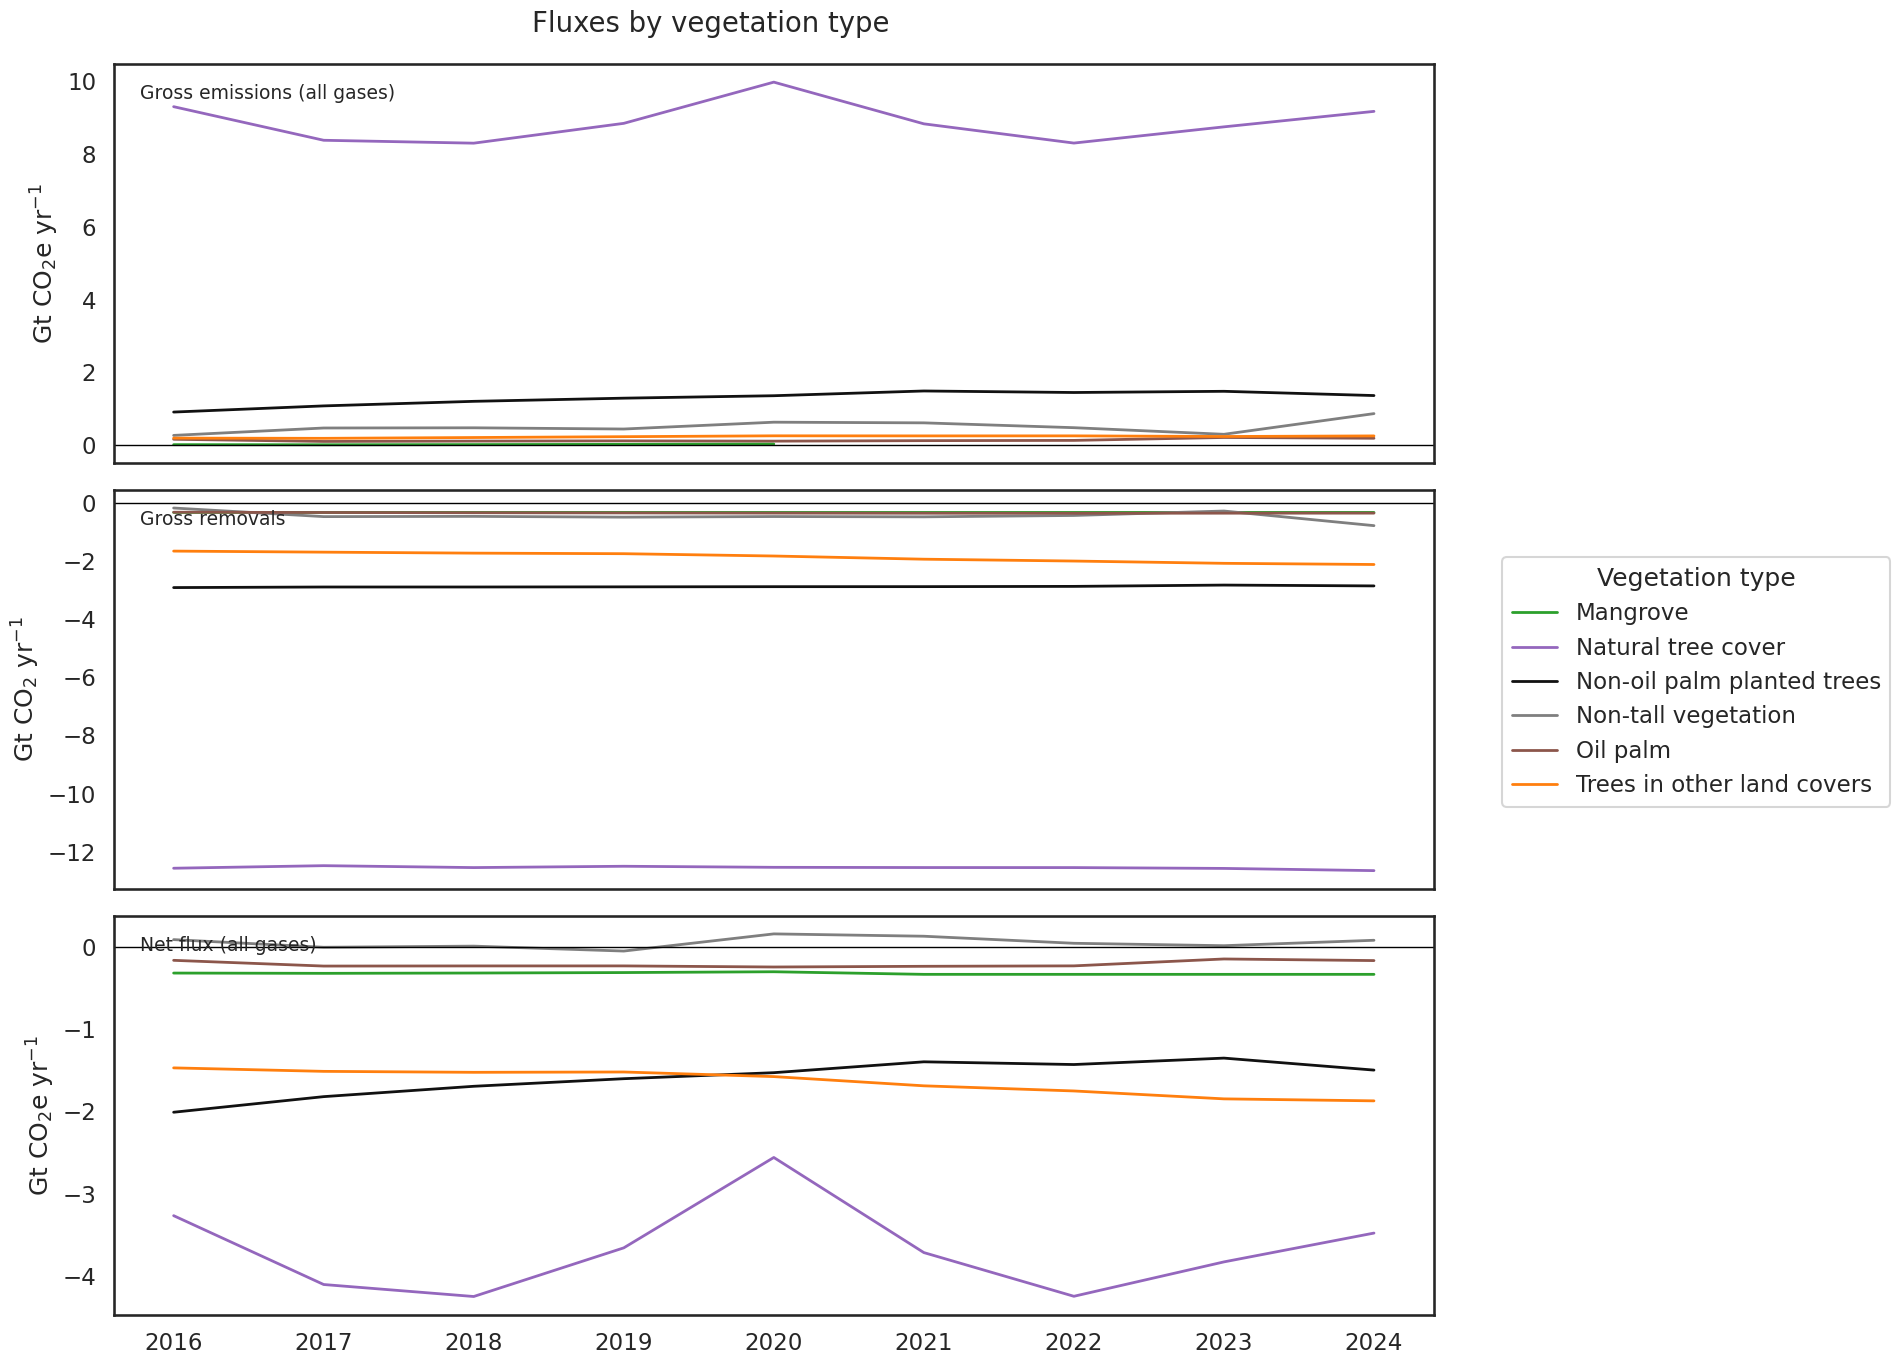

In [19]:
### Global emissions, removals, net flux timeseries by tall vegetation type (natural tree cover, oil palm, trees in other landcovers, non-oil palm planted trees) (panel per flux)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69a5f52d-4db0-832e-8a7e-ee14ee9ac9d0
### and https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69aee45e-ce6c-8325-b1d0-a6c6b0e7ae2e

# ---- Setup ----
context_to_analyze = 'tall_veg_type'

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(15, 14),
    sharex=True
)

# Palette for detailed classes 
tall_veg_palette = {
    "Mangrove": "#2ca02c",                  # green
    "Oil palm": "#8c564b",                    # brown
    "Non-oil palm planted trees": "#111111",                    # ?
    "Natural tree cover": "#9467bd",                   # purple
    "Trees in other land covers": "#ff7f0e",                     # orange
    "Non-tall vegetation": "#7f7f7f",                     # gray
}

panel_labels = [
    gross_emis_all_gases_legend,
    gross_removals_legend,
    net_flux_all_gases_legend
]

df_fig = df_graphs.copy()

# Patterns
emis_pattern = cn.gross_emis_all_C_pools_all_gases_pattern
remov_pattern = cn.gross_removals_all_C_pools_pattern
net_pattern = cn.net_flux_all_C_pools_all_gases_pattern

# ---- Aggregate first ----
df_emis = aggregate_layer(df_fig, emis_pattern)
df_remov = aggregate_layer(df_fig, remov_pattern)
df_net = aggregate_layer(df_fig, net_pattern)

# ---- Map to interpretable labels ----
df_emis[context_to_analyze] = df_emis[context_to_analyze].map(tall_veg_type_dict)
df_remov[context_to_analyze] = df_remov[context_to_analyze].map(tall_veg_type_dict)
df_net[context_to_analyze] = df_net[context_to_analyze].map(tall_veg_type_dict)

# # ---- Remove specific category/ies ----
# def drop_tall(df):
#     return df[~df[context_to_analyze].str.contains("Non-tall vegetation", case=False, na=False)]

# df_emis = drop_tall(df_emis)
# df_remov = drop_tall(df_remov)
# df_net = drop_tall(df_net)

# ---- Reaggregate after collapsing ----
def reaggregate(df):
    return (
        df.groupby([context_to_analyze, "year"], as_index=False)
          .agg({"value_Gt": "sum"})
    )

df_emis = reaggregate(df_emis)
df_remov = reaggregate(df_remov)
df_net = reaggregate(df_net)


# ---- Panel 1 ----
sns.lineplot(
    data=df_emis,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[0],
    linewidth=2,
    legend=False,
    palette=tall_veg_palette
)

axes[0].axhline(0, color="black", linewidth=1)
axes[0].grid(False)
axes[0].set_ylabel("Gt CO$_2$e yr$^{-1}$")

axes[0].text(
    0.02, 0.95,
    panel_labels[0],
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 2 ----
sns.lineplot(
    data=df_remov,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[1],
    linewidth=2,
    legend=False,
    palette=tall_veg_palette
)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].grid(False)
axes[1].set_ylabel("Gt CO$_2$ yr$^{-1}$")

axes[1].text(
    0.02, 0.95,
    panel_labels[1],
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Panel 3 ----
sns.lineplot(
    data=df_net,
    x="year",
    y="value_Gt",
    hue=context_to_analyze,
    ax=axes[2],
    linewidth=2,
    legend=True,
    palette=tall_veg_palette
)

axes[2].axhline(0, color="black", linewidth=1)
axes[2].grid(False)
axes[2].set_ylabel("Gt CO$_2$e yr$^{-1}$")
axes[2].set_xlabel(None)

axes[2].text(
    0.02, 0.95,
    panel_labels[2],
    transform=axes[2].transAxes,
    ha="left",
    va="top",
    fontsize=plt.rcParams["axes.titlesize"] * 0.75,
)

# ---- Single legend outside right ----
handles, labels = axes[2].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Vegetation type",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

axes[2].legend().remove()

fig.suptitle(
    "Fluxes by vegetation type",
    fontsize=plt.rcParams["axes.titlesize"] * 1.1,
    y=0.98
)

plt.tight_layout()
plt.show()

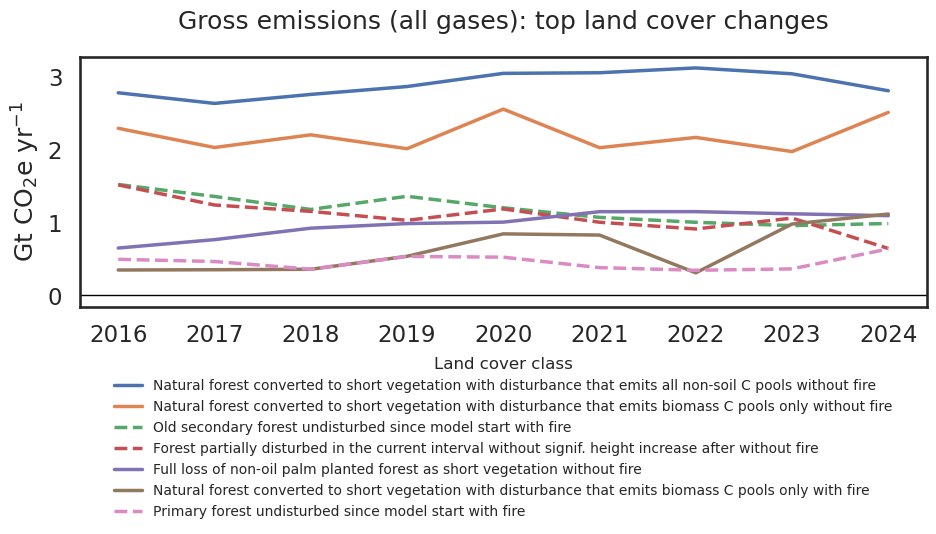

In [74]:
### Global gross emissions timeseries by detailed tree loss categories with highest emissions (i.e. land state node) (single panel)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69b01f34-870c-8326-9946-0d8df6cff4a9

# ---- Setup ----
context_to_analyze = "land_state_meaning"

df_fig = df_graphs.copy()

# Filter to gross emissions (all gases)
df_emis = df_fig[
    df_fig["analysis_layer"] == cn.gross_emis_all_C_pools_all_gases_pattern
].copy()

# # ---- Restrict to land_state_nodes starting with 3 (full tree loss only) ----
# df_emis = df_emis[
#     df_emis["land_state_node"].astype(str).str.startswith("3")
# ]

# ---- Identify top emitting classes ----
top_classes = (
    df_emis
    .groupby(context_to_analyze)["value"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
)

# Restrict dataframe to those classes
df_emis = df_emis[df_emis[context_to_analyze].isin(top_classes)]

# ---- Create linestyle variable ----
df_emis["line_type"] = np.where(
    df_emis["land_state_detailed_class"] == "tree_loss",
    "solid",  # Tree loss is solid line
    "dashed"  # Any other category is dashed line
)

# ---- Aggregate ----
df_emis_ts = (
    df_emis
    .groupby([context_to_analyze, "line_type", "year"], as_index=False)
    .agg({"value": "sum"})
)

df_emis_ts["value_Gt"] = df_emis_ts["value"] / 1e9

plt.figure(figsize=(10, 6))
ax = plt.gca()

palette = sns.color_palette(n_colors=len(top_classes))
color_map = dict(zip(top_classes, palette))

for cls in top_classes:

    sub = df_emis_ts[df_emis_ts[context_to_analyze] == cls]

    # Determine linestyle from detailed class
    detailed_class = df_emis[
        df_emis[context_to_analyze] == cls
    ]["land_state_detailed_class"].iloc[0]

    linestyle = "-" if detailed_class == "tree_loss" else "--"

    ax.plot(
        sub["year"],
        sub["value_Gt"],
        label=cls,
        color=color_map[cls],
        linestyle=linestyle,
        linewidth=2.5
    )

ax.axhline(0, color="black", linewidth=1)
ax.grid(False)

ax.set_xlabel(None)
ax.set_ylabel("Gt CO$_2$e yr$^{-1}$")
ax.set_title("Gross emissions (all gases): top land cover changes", pad=20)

ax.legend(
    title="Land cover class",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    fontsize=10,
    title_fontsize=12,
    frameon=False
)

plt.tight_layout()
plt.show()
# df_emis_ts

    country_name         value
165       Russia -1.214925e+09
41         China -1.101614e+09
208          USA -9.233729e+08
27        Brazil -7.026291e+08
90         India -4.083534e+08
35        Canada -3.030077e+08
91     Indonesia -2.492412e+08
128       Mexico -2.277857e+08
99         Japan -1.634428e+08
40         Chile -1.383193e+08
['DR Congo', 'Central African Republic', 'Bolivia', 'Angola', 'Laos', 'Zambia', 'South Sudan', 'Liberia', 'Cambodia', 'Mozambique']
['Russia', 'China', 'USA', 'Brazil', 'India', 'Canada', 'Indonesia', 'Mexico', 'Japan', 'Chile']


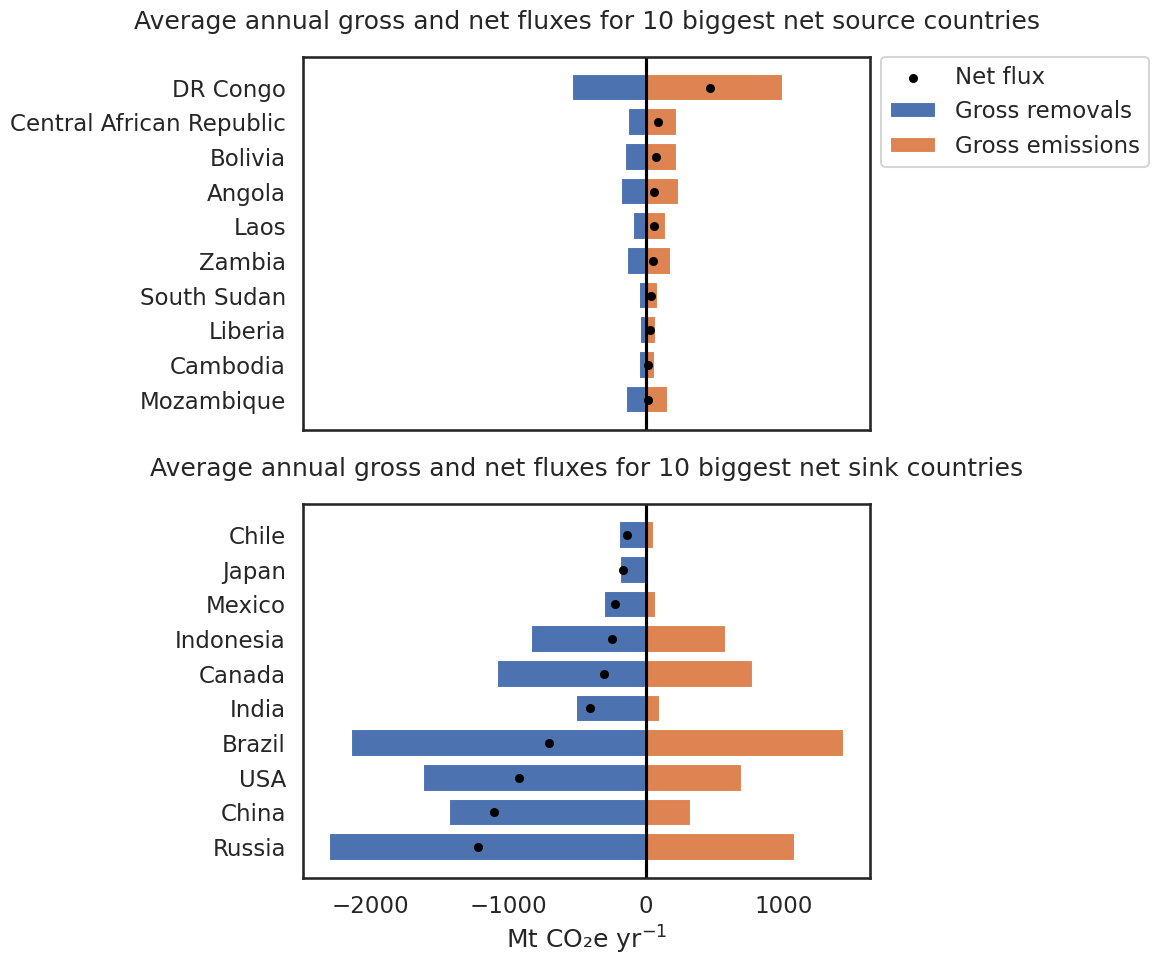

In [67]:
### Graph gross and net fluxes for highest net source and net sink countries
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69af7427-a74c-8325-8ac3-40a9fd7bddf9


# Filter to net flux (all gases)
df_net = df_graphs[df_graphs["analysis_layer"] == cn.net_flux_all_C_pools_all_gases_pattern].copy()

net_by_country = (
    df_net.groupby("country_name", as_index=False)["value"]
    .sum()
)

# Convert to annual average (Mg CO2e/yr)
net_by_country["value"] = net_by_country["value"]/years

# Remove no_country rows if present
net_by_country = net_by_country[net_by_country["country_name"] != "no_country"]

# Top 10 net sources
top10_sources = (
    net_by_country
    .sort_values("value", ascending=False)
    .head(10)
)
# print(top10_sources)

# Top 10 net sinks
top10_sinks = (
    net_by_country
    .sort_values("value", ascending=True)
    .head(10)
)
print(top10_sinks)

top10_source_countries = top10_sources["country_name"].tolist()
print(top10_source_countries)

top10_sink_countries = top10_sinks["country_name"].tolist()
print(top10_sink_countries)

# ---- Gross emissions ----
df_emis = df_fig[
    df_fig["analysis_layer"] == cn.gross_emis_all_C_pools_all_gases_pattern
]

# Average annual gross emissions for top 10 net source countries (Mg CO2e/yr)
emis_by_source_country = (
    df_emis[df_emis["country_name"].isin(top10_source_countries)]
    .groupby("country_name")["value"]
    .sum()
    /years
)

# Average annual gross emissions for top 10 net sink countries (Mg CO2e/yr)
emis_by_sink_country = (
    df_emis[df_emis["country_name"].isin(top10_sink_countries)]
    .groupby("country_name")["value"]
    .sum()
    /years
)

# ---- Gross removals ----
df_rem = df_fig[
    df_fig["analysis_layer"] == cn.gross_removals_all_C_pools_pattern
]

# Average annual gross removals for top 10 net source countries (Mg CO2/yr)
rem_by_source_country = (
    df_rem[df_rem["country_name"].isin(top10_source_countries)]
    .groupby("country_name")["value"]
    .sum()
    /years
)

# Average annual gross removals for top 10 net sink countries (Mg CO2/yr)
rem_by_sink_country = (
    df_rem[df_rem["country_name"].isin(top10_sink_countries)]
    .groupby("country_name")["value"]
    .sum()
    /years
)


### Plotting tables

# ---- Sources dataframe ----
df_plot_sources = (
    top10_sources
    .set_index("country_name")
    .rename(columns={"value": "net_flux_Mg_CO2e_yr"})
)

df_plot_sources["gross_emissions"] = emis_by_source_country
df_plot_sources["gross_removals"] = rem_by_source_country


# ---- Sinks dataframe ----
df_plot_sinks = (
    top10_sinks
    .set_index("country_name")
    .rename(columns={"value": "net_flux_Mg_CO2e_yr"})
)

df_plot_sinks["gross_emissions"] = emis_by_sink_country
df_plot_sinks["gross_removals"] = rem_by_sink_country


# Convert to Mt CO2e
df_plot_sources = df_plot_sources / 1e6
df_plot_sinks = df_plot_sinks / 1e6


# Sort for plotting
df_plot_sources = df_plot_sources.sort_values("net_flux_Mg_CO2e_yr")
df_plot_sinks = df_plot_sinks.sort_values("net_flux_Mg_CO2e_yr")

# ---- Plot ----
fig, axes = plt.subplots(
    nrows=2,
    figsize=(12, 10),
    sharex=True
)

# ---------------- Sources ----------------
ax = axes[0]

ax.barh(df_plot_sources.index, df_plot_sources["gross_removals"], label="Gross removals")
ax.barh(df_plot_sources.index, df_plot_sources["gross_emissions"], label="Gross emissions")

ax.scatter(
    df_plot_sources["net_flux_Mg_CO2e_yr"],
    df_plot_sources.index,
    color="black",
    s=25,
    zorder=3,
    label="Net flux"
)

ax.axvline(0, color="black")

ax.set_title("Average annual gross and net fluxes for 10 biggest net source countries", pad=20)
ax.set_ylabel("")

ax.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

# ---------------- Sinks ----------------
ax = axes[1]

ax.barh(df_plot_sinks.index, df_plot_sinks["gross_removals"])
ax.barh(df_plot_sinks.index, df_plot_sinks["gross_emissions"])

ax.scatter(
    df_plot_sinks["net_flux_Mg_CO2e_yr"],
    df_plot_sinks.index,
    color="black",
    s=25,
    zorder=3
)

ax.axvline(0, color="black")

ax.set_title("Average annual gross and net fluxes for 10 biggest net sink countries", pad=20)
ax.set_xlabel("Mt CO₂e yr$^{-1}$")
ax.set_ylabel("")

plt.tight_layout()
plt.show()